# HPO Top vs Bottom Quartile Analysis

This notebook compares the distribution of HPO settings in the bottom 25% and top 25% of each fitness target. The middle 50% is intentionally ignored so the plots focus on contrast rather than weak global trends.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


csv_path = Path('../log/cache.csv')
df = pd.read_csv(csv_path)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values('iteration').reset_index(drop=True)

fitness_col = 'avg_fitness'
fitness_cols = [
    col for col in df.columns
    if col.endswith('_fitness') and col != fitness_col
]
target_cols = [fitness_col, *fitness_cols]
fitness_labels = {
    fitness_col: 'Average fitness',
    **{col: col.replace('_fitness', '') for col in fitness_cols},
}

categorical_cols = {'timestamp', 'eliminator_type', 'selection_type'}
for col in df.columns:
    if col not in categorical_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Loaded {len(df)} rows')
print('Fitness targets:', target_cols)
df.head()

Loaded 201 rows
Fitness targets: ['avg_fitness', '48xxx_random_constraints.job_fitness', '51000_rijeka_random_constraints.job_fitness']


,iteration,timestamp,avg_fitness,general_MAX_CLUSTER_DISTANCE,general_MAX_CLUSTER_JOIN_DISTANCE,populationSize,generations,newChromosomes,eliminator_type,eliminator_elitism,...,crossover_child4_k,crossover_child4_p,crossover_child4_weight,crossover_child5_k,crossover_child5_p,crossover_child5_weight,selection_type,selection_tournamentSize,48xxx_random_constraints.job_fitness,51000_rijeka_random_constraints.job_fitness
0,1,2026-06-17 15:24:09.817278,64.624848,5.511144,15.099063,5000,2000,20,EliteEliminator,8,...,6,0.319196,0.615276,5,0.525631,0.350627,TournamentSelection,3,101.568046,27.681649
1,2,2026-06-17 15:34:18.902397,59.756477,10.211272,17.899675,200,8000,26,EliteEliminator,4,...,4,0.671720,0.252349,3,0.567840,0.545844,TournamentSelection,2,94.178730,25.334223
2,3,2026-06-17 15:35:04.985979,60.450161,5.893158,18.537005,50,2000,6,EliteEliminator,4,...,4,0.676526,0.727664,6,0.565126,0.538343,TournamentSelection,4,94.568332,26.331989
3,4,2026-06-17 16:07:27.943578,61.124880,9.074308,18.908655,50,500,24,EliteEliminator,10,...,7,0.364541,0.414391,7,0.826165,0.110284,TournamentSelection,5,96.339489,25.910270
4,5,2026-06-17 16:15:22.501249,62.837381,7.787873,15.956559,200,8000,18,EliteGeometricEliminator,13,...,2,0.686399,0.396045,7,0.247864,0.807092,TournamentSelection,3,99.389062,26.285700


In [2]:
QUANTILE = 0.25
GROUP_ORDER = ['Bottom 25%', 'Top 25%']
GROUP_COLORS = {
    'Bottom 25%': '#E45756',
    'Top 25%': '#4C78A8',
}


def top_bottom_frame(data, target_col, quantile=QUANTILE):
    base = data.dropna(subset=[target_col]).copy()
    low_threshold = base[target_col].quantile(quantile)
    high_threshold = base[target_col].quantile(1 - quantile)

    bottom = base[base[target_col] <= low_threshold].copy()
    top = base[base[target_col] >= high_threshold].copy()
    bottom['quartile_group'] = 'Bottom 25%'
    top['quartile_group'] = 'Top 25%'
    grouped = pd.concat([bottom, top], ignore_index=True)
    return grouped, low_threshold, high_threshold


def existing_columns(data, columns):
    return [col for col in columns if col in data.columns]


def as_axes_grid(axes, n_rows, n_cols):
    axes = np.asarray(axes, dtype=object)
    if n_rows == 1 and n_cols == 1:
        return axes.reshape(1, 1)
    if n_rows == 1:
        return axes.reshape(1, n_cols)
    if n_cols == 1:
        return axes.reshape(n_rows, 1)
    return axes


def plot_numeric_top_bottom(data, feature_cols, title, target_cols=target_cols, bins=12):
    feature_cols = existing_columns(data, feature_cols)
    if not feature_cols:
        print(f'No available columns for {title}')
        return

    fig, axes = plt.subplots(
        len(target_cols),
        len(feature_cols),
        figsize=(5 * len(feature_cols), 3.8 * len(target_cols)),
        squeeze=False,
    )

    for row, target_col in enumerate(target_cols):
        grouped, low_threshold, high_threshold = top_bottom_frame(data, target_col)
        target_label = fitness_labels.get(target_col, target_col)
        for col_idx, feature_col in enumerate(feature_cols):
            ax = axes[row, col_idx]
            plotted = False
            for group in GROUP_ORDER:
                values = grouped.loc[grouped['quartile_group'] == group, feature_col].dropna()
                if values.empty:
                    continue
                ax.hist(
                    values,
                    bins=bins,
                    density=True,
                    alpha=0.45,
                    color=GROUP_COLORS[group],
                    label=f'{group} (n={len(values)})',
                )
                ax.axvline(values.mean(), color=GROUP_COLORS[group], linewidth=2)
                plotted = True

            if not plotted:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

            ax.set_title(f'{target_label}\n{feature_col}')
            ax.set_xlabel(feature_col)
            ax.set_ylabel('Density')
            ax.grid(True, axis='y', alpha=0.3)
            if row == 0 and col_idx == 0:
                ax.legend()

    fig.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_categorical_top_bottom(data, feature_cols, title, target_cols=target_cols):
    feature_cols = existing_columns(data, feature_cols)
    if not feature_cols:
        print(f'No available columns for {title}')
        return

    fig, axes = plt.subplots(
        len(target_cols),
        len(feature_cols),
        figsize=(5.5 * len(feature_cols), 3.8 * len(target_cols)),
        squeeze=False,
    )

    for row, target_col in enumerate(target_cols):
        grouped, low_threshold, high_threshold = top_bottom_frame(data, target_col)
        target_label = fitness_labels.get(target_col, target_col)
        for col_idx, feature_col in enumerate(feature_cols):
            ax = axes[row, col_idx]
            table = pd.crosstab(
                grouped[feature_col],
                grouped['quartile_group'],
                normalize='columns',
            ).reindex(columns=GROUP_ORDER, fill_value=0)
            if table.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                table.plot(kind='bar', ax=ax, color=[GROUP_COLORS[group] for group in GROUP_ORDER])
            ax.set_title(f'{target_label}\n{feature_col}')
            ax.set_xlabel(feature_col)
            ax.set_ylabel('Within-group share')
            ax.tick_params(axis='x', rotation=25)
            ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


def top_bottom_numeric_summary(data, feature_cols, target_cols=target_cols):
    rows = []
    feature_cols = existing_columns(data, feature_cols)
    for target_col in target_cols:
        grouped, low_threshold, high_threshold = top_bottom_frame(data, target_col)
        for feature_col in feature_cols:
            bottom = grouped.loc[grouped['quartile_group'] == 'Bottom 25%', feature_col].dropna()
            top = grouped.loc[grouped['quartile_group'] == 'Top 25%', feature_col].dropna()
            if len(bottom) < 2 or len(top) < 2:
                continue
            pooled_std = np.sqrt((bottom.var(ddof=1) + top.var(ddof=1)) / 2)
            cohen_d = np.nan if pooled_std == 0 else (top.mean() - bottom.mean()) / pooled_std
            rows.append(
                {
                    'fitness_target': fitness_labels.get(target_col, target_col),
                    'feature': feature_col,
                    'bottom_mean': bottom.mean(),
                    'top_mean': top.mean(),
                    'mean_delta': top.mean() - bottom.mean(),
                    'cohen_d': cohen_d,
                    'bottom_median': bottom.median(),
                    'top_median': top.median(),
                    'n_bottom': len(bottom),
                    'n_top': len(top),
                }
            )
    summary = pd.DataFrame(rows)
    if not summary.empty:
        summary = summary.sort_values('cohen_d', key=lambda s: s.abs(), ascending=False)
    return summary


def top_bottom_categorical_summary(data, feature_cols, target_cols=target_cols):
    tables = {}
    feature_cols = existing_columns(data, feature_cols)
    for target_col in target_cols:
        grouped, low_threshold, high_threshold = top_bottom_frame(data, target_col)
        for feature_col in feature_cols:
            table = pd.crosstab(
                grouped[feature_col],
                grouped['quartile_group'],
                normalize='columns',
            ).reindex(columns=GROUP_ORDER, fill_value=0)
            table['top_minus_bottom'] = table['Top 25%'] - table['Bottom 25%']
            tables[(fitness_labels.get(target_col, target_col), feature_col)] = table.sort_values(
                'top_minus_bottom',
                key=lambda s: s.abs(),
                ascending=False,
            )
    return tables


def plot_top_bottom_mean_bars(data, feature_cols, title, target_cols=target_cols):
    feature_cols = existing_columns(data, feature_cols)
    if not feature_cols:
        print(f'No available columns for {title}')
        return

    fig, axes = plt.subplots(
        len(target_cols),
        1,
        figsize=(max(12, 0.75 * len(feature_cols)), 4 * len(target_cols)),
        squeeze=False,
    )
    x = np.arange(len(feature_cols))
    width = 0.38

    for row, target_col in enumerate(target_cols):
        grouped, low_threshold, high_threshold = top_bottom_frame(data, target_col)
        means = grouped.groupby('quartile_group')[feature_cols].mean().reindex(GROUP_ORDER)
        ax = axes[row, 0]
        ax.bar(x - width / 2, means.loc['Bottom 25%'], width, label='Bottom 25%', color=GROUP_COLORS['Bottom 25%'])
        ax.bar(x + width / 2, means.loc['Top 25%'], width, label='Top 25%', color=GROUP_COLORS['Top 25%'])
        ax.set_title(f'{fitness_labels.get(target_col, target_col)} - mean feature values')
        ax.set_xticks(x)
        ax.set_xticklabels(feature_cols, rotation=35, ha='right')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend()

    fig.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()


In [3]:
analysis_df = df.copy()

if {'populationSize', 'generations'}.issubset(analysis_df.columns):
    analysis_df['search_effort'] = analysis_df['populationSize'] * analysis_df['generations']
if {'newChromosomes', 'generations'}.issubset(analysis_df.columns):
    analysis_df['total_new_chromosomes'] = analysis_df['newChromosomes'] * analysis_df['generations']
if {'newChromosomes', 'populationSize'}.issubset(analysis_df.columns):
    analysis_df['new_chromosome_rate'] = analysis_df['newChromosomes'] / analysis_df['populationSize'].replace(0, pd.NA)

mutator_weight_cols = ['mutator_child1_weight', 'mutator_child2_weight']
if all(col in analysis_df.columns for col in mutator_weight_cols):
    mutator_weight_sum = analysis_df[mutator_weight_cols].sum(axis=1).replace(0, pd.NA)
    analysis_df['mutator_child1_weight_share'] = analysis_df['mutator_child1_weight'] / mutator_weight_sum
    analysis_df['mutator_child2_weight_share'] = analysis_df['mutator_child2_weight'] / mutator_weight_sum
    analysis_df['mutator_average_num_mutations'] = (
        analysis_df['mutator_child1_numMutations'] * analysis_df['mutator_child1_weight_share']
        + analysis_df['mutator_child2_numMutations'] * analysis_df['mutator_child2_weight_share']
    )
    analysis_df['mutator_average_probability'] = (
        analysis_df['mutator_child1_p'] * analysis_df['mutator_child1_weight_share']
        + analysis_df['mutator_child2_p'] * analysis_df['mutator_child2_weight_share']
    )
    analysis_df['mutator_intensity'] = (
        analysis_df['mutator_average_num_mutations']
        * analysis_df['mutator_average_probability']
    )

crossover_weight_cols = [f'crossover_child{i}_weight' for i in range(1, 6)]
if all(col in analysis_df.columns for col in crossover_weight_cols):
    crossover_weight_sum = analysis_df[crossover_weight_cols].sum(axis=1).replace(0, pd.NA)
    for i in range(1, 6):
        analysis_df[f'crossover_child{i}_weight_share'] = analysis_df[f'crossover_child{i}_weight'] / crossover_weight_sum

    analysis_df['crossover_child1_expected_k'] = 1 / analysis_df['crossover_child1_geoP']
    analysis_df['crossover_child2_expected_k'] = 1 / analysis_df['crossover_child2_geoP']
    analysis_df['crossover_expected_column_switch_pressure'] = (
        analysis_df['crossover_child1_weight_share']
        * analysis_df['crossover_child1_expected_k']
        * analysis_df['crossover_child1_crossoverProb']
        + analysis_df['crossover_child5_weight_share']
        * analysis_df['crossover_child5_k']
        * analysis_df['crossover_child5_p']
    )
    analysis_df['crossover_expected_row_switch_pressure'] = (
        analysis_df['crossover_child2_weight_share']
        * analysis_df['crossover_child2_expected_k']
        * analysis_df['crossover_child2_crossoverProb']
        + analysis_df['crossover_child4_weight_share']
        * analysis_df['crossover_child4_k']
        * analysis_df['crossover_child4_p']
    )
    analysis_df['crossover_single_point_pressure'] = (
        analysis_df['crossover_child3_weight_share'] * analysis_df['crossover_child3_p']
    )

for col in ['general_MAX_CLUSTER_DISTANCE', 'general_MAX_CLUSTER_JOIN_DISTANCE']:
    if col in analysis_df.columns:
        analysis_df[f'{col}_rounded'] = analysis_df[col].round().astype('Int64')

analysis_df.head()

,iteration,timestamp,avg_fitness,general_MAX_CLUSTER_DISTANCE,general_MAX_CLUSTER_JOIN_DISTANCE,populationSize,generations,newChromosomes,eliminator_type,eliminator_elitism,...,crossover_child3_weight_share,crossover_child4_weight_share,crossover_child5_weight_share,crossover_child1_expected_k,crossover_child2_expected_k,crossover_expected_column_switch_pressure,crossover_expected_row_switch_pressure,crossover_single_point_pressure,general_MAX_CLUSTER_DISTANCE_rounded,general_MAX_CLUSTER_JOIN_DISTANCE_rounded
0,1,2026-06-17 15:24:09.817278,64.624848,5.511144,15.099063,5000,2000,20,EliteEliminator,8,...,0.103239,0.196175,0.111794,1.561546,2.380060,0.360030,0.443501,0.068901,6,15
1,2,2026-06-17 15:34:18.902397,59.756477,10.211272,17.899675,200,8000,26,EliteEliminator,4,...,0.274233,0.122337,0.264621,1.743197,3.702751,0.703991,0.682806,0.131789,10,18
2,3,2026-06-17 15:35:04.985979,60.450161,5.893158,18.537005,50,2000,6,EliteEliminator,4,...,0.222511,0.187093,0.138416,3.830645,6.889782,1.166908,1.122689,0.139476,6,19
3,4,2026-06-17 16:07:27.943578,61.124880,9.074308,18.908655,50,500,24,EliteEliminator,10,...,0.343412,0.160225,0.042641,1.314797,9.675976,0.419844,2.535302,0.268416,9,19
4,5,2026-06-17 16:15:22.501249,62.837381,7.787873,15.956559,200,8000,18,EliteGeometricEliminator,13,...,0.048531,0.164104,0.334424,2.654968,1.309228,1.108517,0.237543,0.037058,8,16


## GA Budget And Base Parameters

Instead of plotting each value against fitness, compare whether the top quartile spends a different search budget than the bottom quartile.

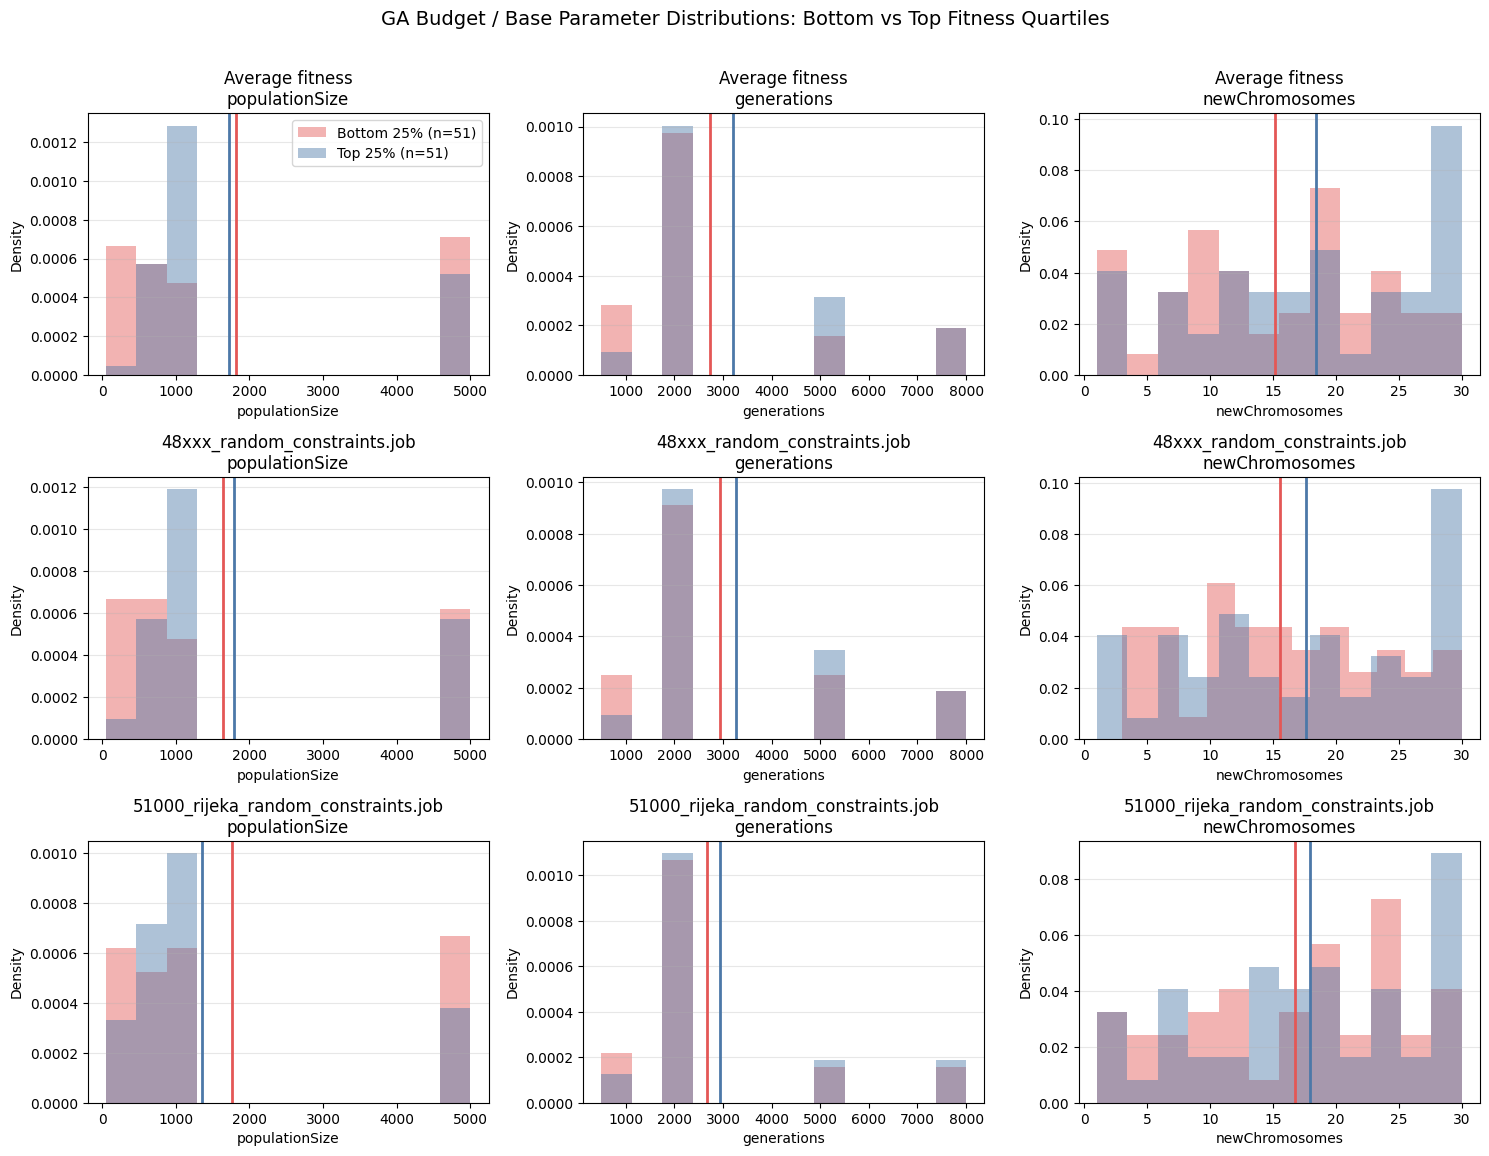

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
2,Average fitness,newChromosomes,15.137255,18.372549,3.235294,0.371997,16.0,20.0,51,51
5,48xxx_random_constraints.job,newChromosomes,15.529412,17.627451,2.098039,0.240557,16.0,19.0,51,51
6,51000_rijeka_random_constraints.job,populationSize,1759.803922,1358.823529,-400.980392,-0.217878,1000.0,1000.0,51,51
1,Average fitness,generations,2735.294118,3205.882353,470.588235,0.212101,2000.0,2000.0,51,51
4,48xxx_random_constraints.job,generations,2941.176471,3264.705882,323.529412,0.144542,2000.0,2000.0,51,51
8,51000_rijeka_random_constraints.job,newChromosomes,16.705882,17.901961,1.196078,0.140948,18.0,18.0,51,51
7,51000_rijeka_random_constraints.job,generations,2676.470588,2941.176471,264.705882,0.124613,2000.0,2000.0,51,51
3,48xxx_random_constraints.job,populationSize,1639.215686,1786.274510,147.058824,0.076764,500.0,1000.0,51,51
0,Average fitness,populationSize,1815.686275,1726.470588,-89.215686,-0.046187,500.0,1000.0,51,51


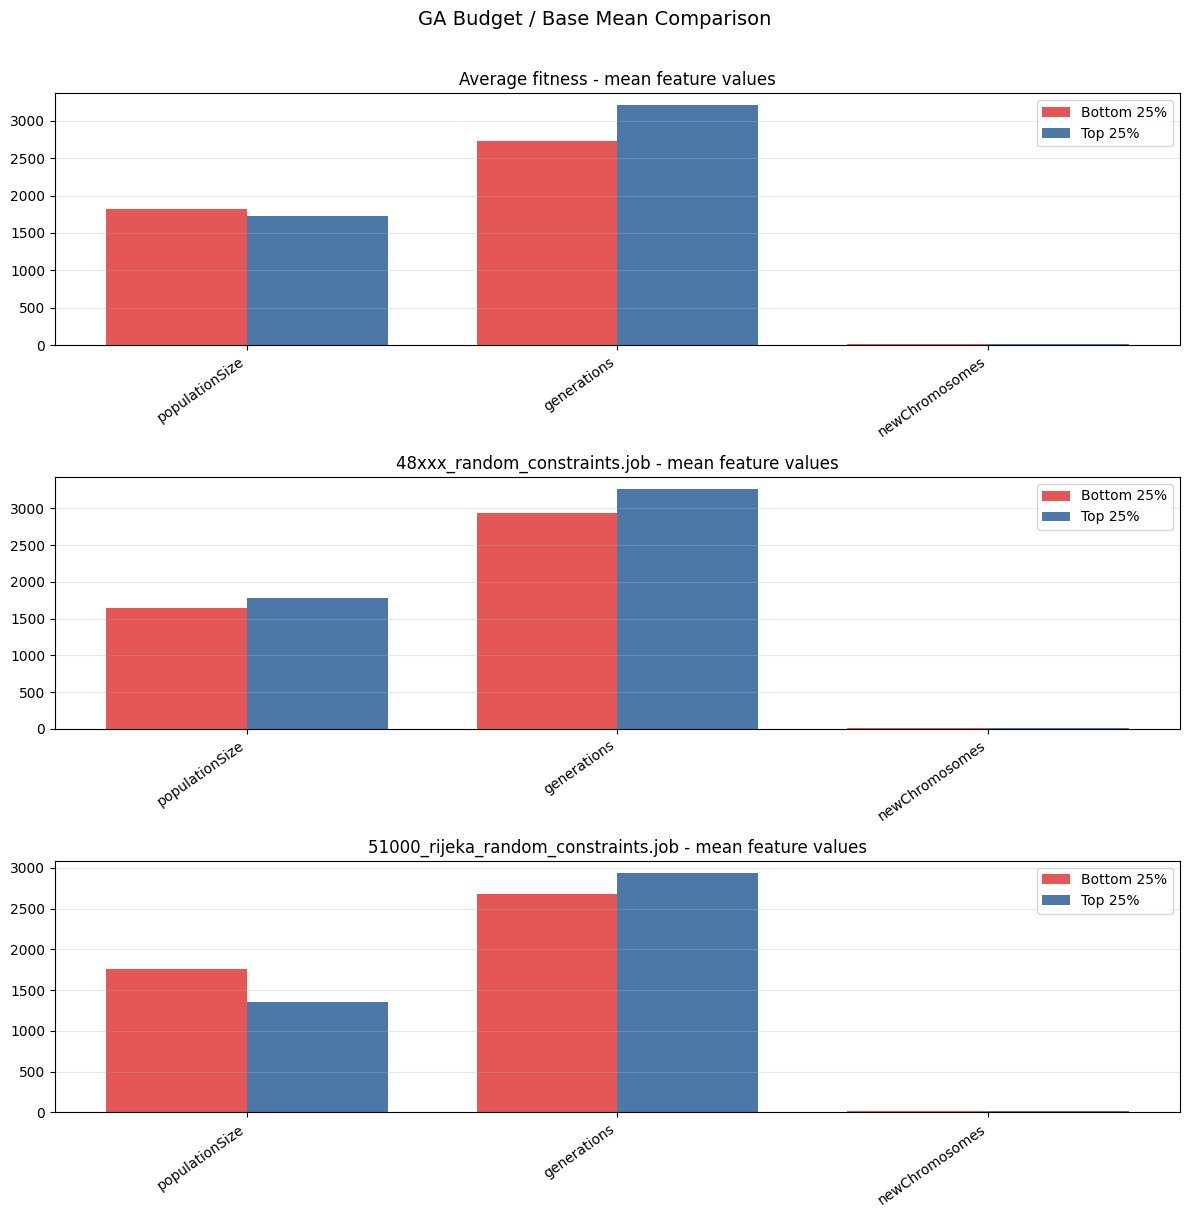

In [13]:
ga_budget_features = [
    'populationSize',
    'generations',
    'newChromosomes',
    # 'search_effort',
    # 'total_new_chromosomes',
    # 'new_chromosome_rate',
]

plot_numeric_top_bottom(
    analysis_df,
    ga_budget_features,
    'GA Budget / Base Parameter Distributions: Bottom vs Top Fitness Quartiles',
)

display(top_bottom_numeric_summary(analysis_df, ga_budget_features).head(30))
plot_top_bottom_mean_bars(
    analysis_df,
    ga_budget_features,
    'GA Budget / Base Mean Comparison',
)

## Selection Settings

`selection_tournamentSize` is only meaningful for `TournamentSelection`, so tournament size is analyzed on that subset.

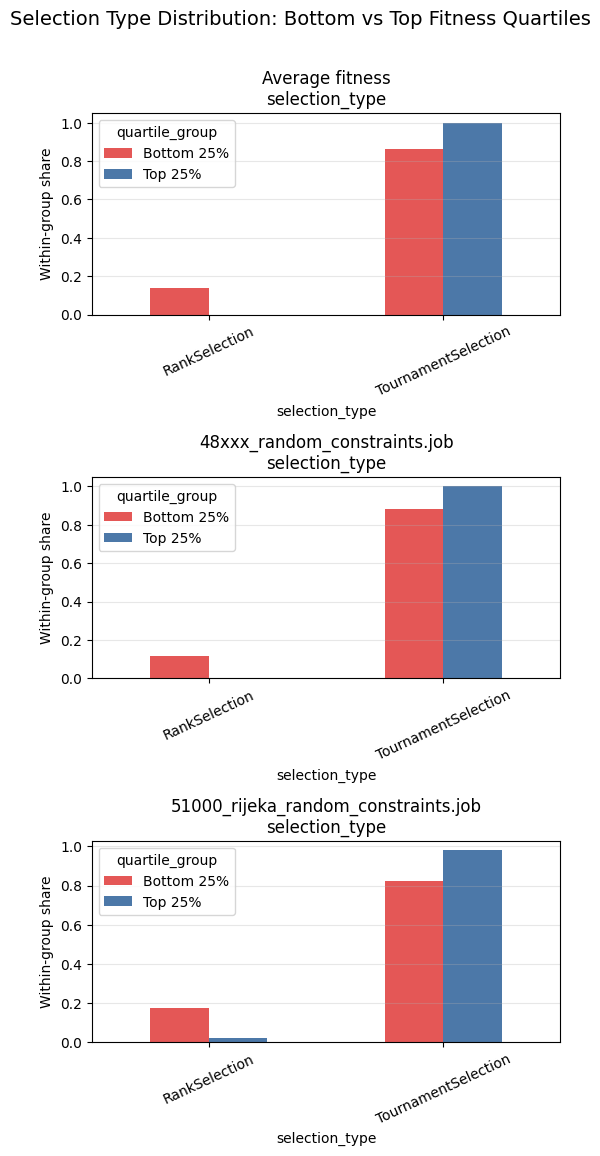

Average fitness - selection_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
selection_type,,,
RankSelection,0.137255,0.0,-0.137255
TournamentSelection,0.862745,1.0,0.137255


48xxx_random_constraints.job - selection_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
selection_type,,,
TournamentSelection,0.882353,1.0,0.117647
RankSelection,0.117647,0.0,-0.117647


51000_rijeka_random_constraints.job - selection_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
selection_type,,,
RankSelection,0.176471,0.019608,-0.156863
TournamentSelection,0.823529,0.980392,0.156863


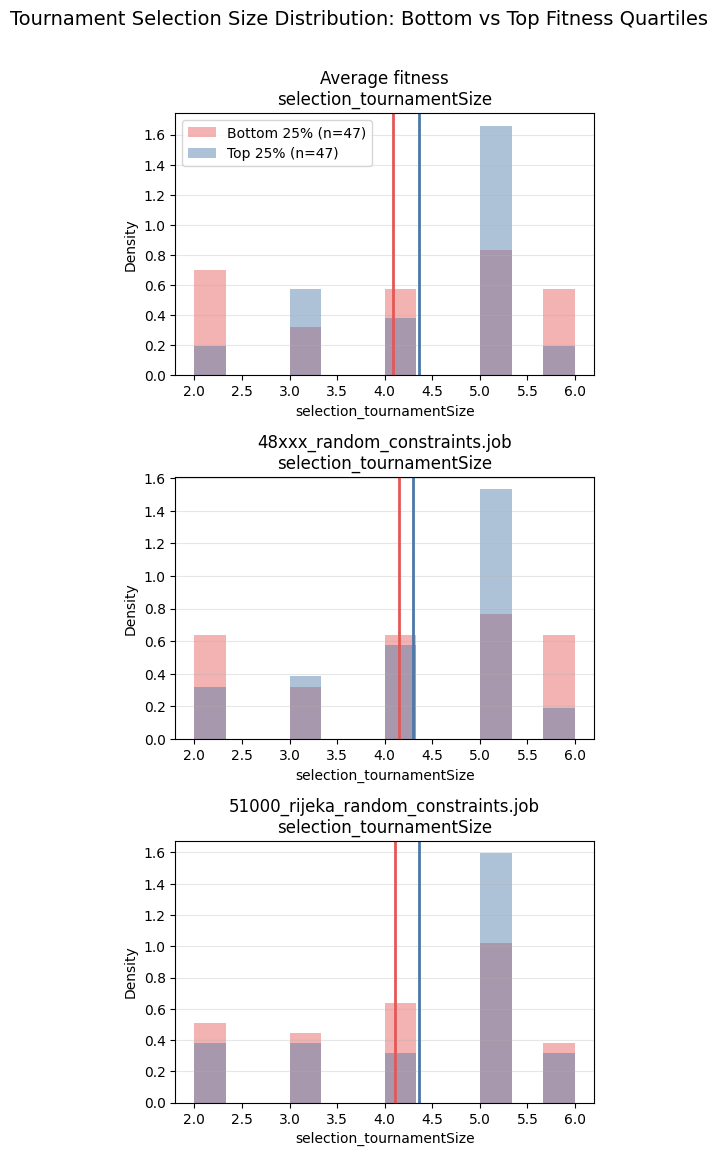

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
0,Average fitness,selection_tournamentSize,4.085106,4.361702,0.276596,0.216250,4.0,5.0,47,47
2,51000_rijeka_random_constraints.job,selection_tournamentSize,4.106383,4.361702,0.255319,0.201766,4.0,5.0,47,47
1,48xxx_random_constraints.job,selection_tournamentSize,4.148936,4.297872,0.148936,0.115195,4.0,5.0,47,47


In [5]:
plot_categorical_top_bottom(
    analysis_df,
    ['selection_type'],
    'Selection Type Distribution: Bottom vs Top Fitness Quartiles',
)

selection_tables = top_bottom_categorical_summary(analysis_df, ['selection_type'])
for (target_label, feature_col), table in selection_tables.items():
    print(f'{target_label} - {feature_col}')
    display(table)

tournament_only = analysis_df[analysis_df['selection_type'] == 'TournamentSelection'].copy()
plot_numeric_top_bottom(
    tournament_only,
    ['selection_tournamentSize'],
    'Tournament Selection Size Distribution: Bottom vs Top Fitness Quartiles',
)
display(top_bottom_numeric_summary(tournament_only, ['selection_tournamentSize']))


## Eliminator Settings

Eliminator parameters are conditional: `elitism` only belongs to `EliteEliminator`, while `survivalRate` and `p` belong to `EliteGeometricEliminator`.

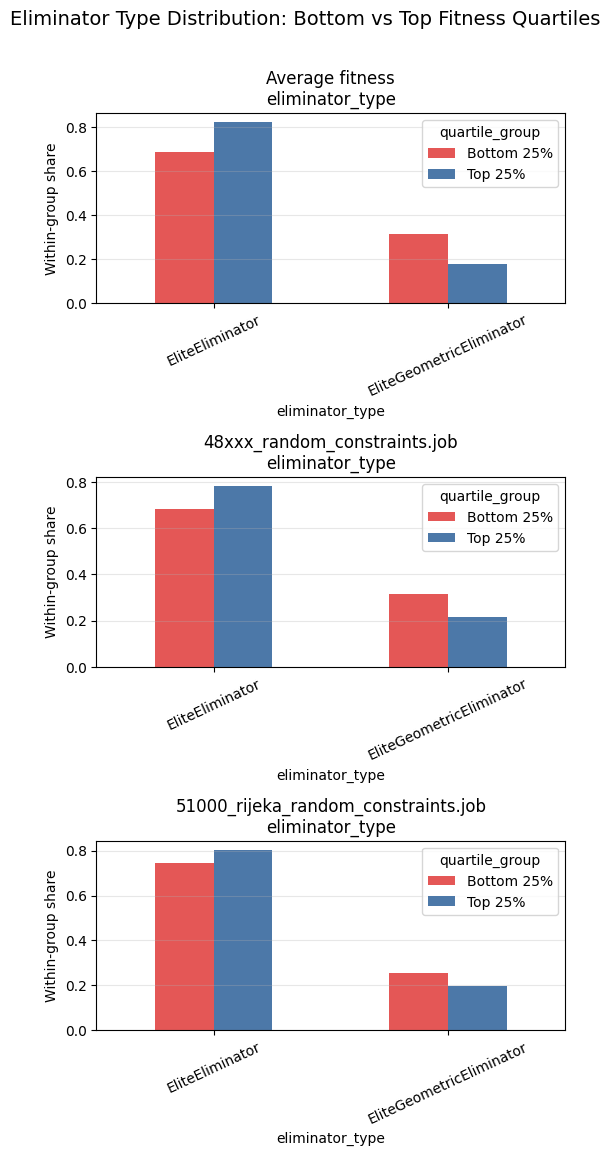

Average fitness - eliminator_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
eliminator_type,,,
EliteGeometricEliminator,0.313725,0.176471,-0.137255
EliteEliminator,0.686275,0.823529,0.137255


48xxx_random_constraints.job - eliminator_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
eliminator_type,,,
EliteEliminator,0.686275,0.784314,0.098039
EliteGeometricEliminator,0.313725,0.215686,-0.098039


51000_rijeka_random_constraints.job - eliminator_type


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
eliminator_type,,,
EliteEliminator,0.745098,0.803922,0.058824
EliteGeometricEliminator,0.254902,0.196078,-0.058824


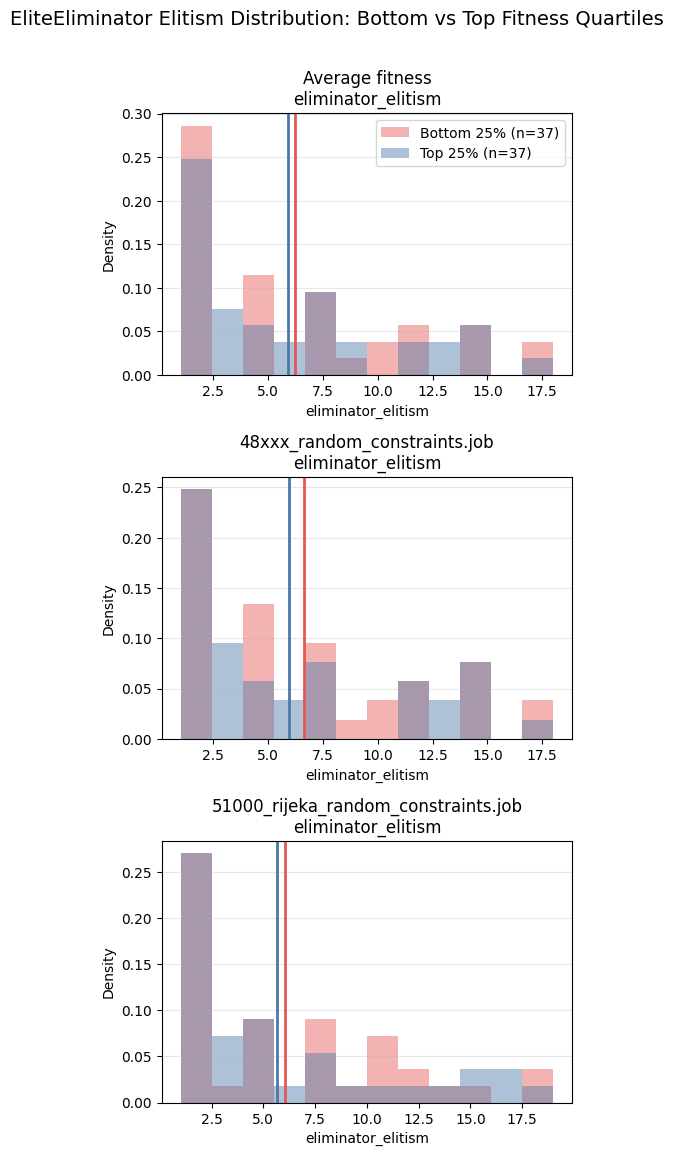

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
1,48xxx_random_constraints.job,eliminator_elitism,6.621622,5.945946,-0.675676,-0.127799,5.0,4.0,37,37
2,51000_rijeka_random_constraints.job,eliminator_elitism,6.027027,5.675676,-0.351351,-0.065701,4.0,3.0,37,37
0,Average fitness,eliminator_elitism,6.216216,5.891892,-0.324324,-0.062873,5.0,5.0,37,37


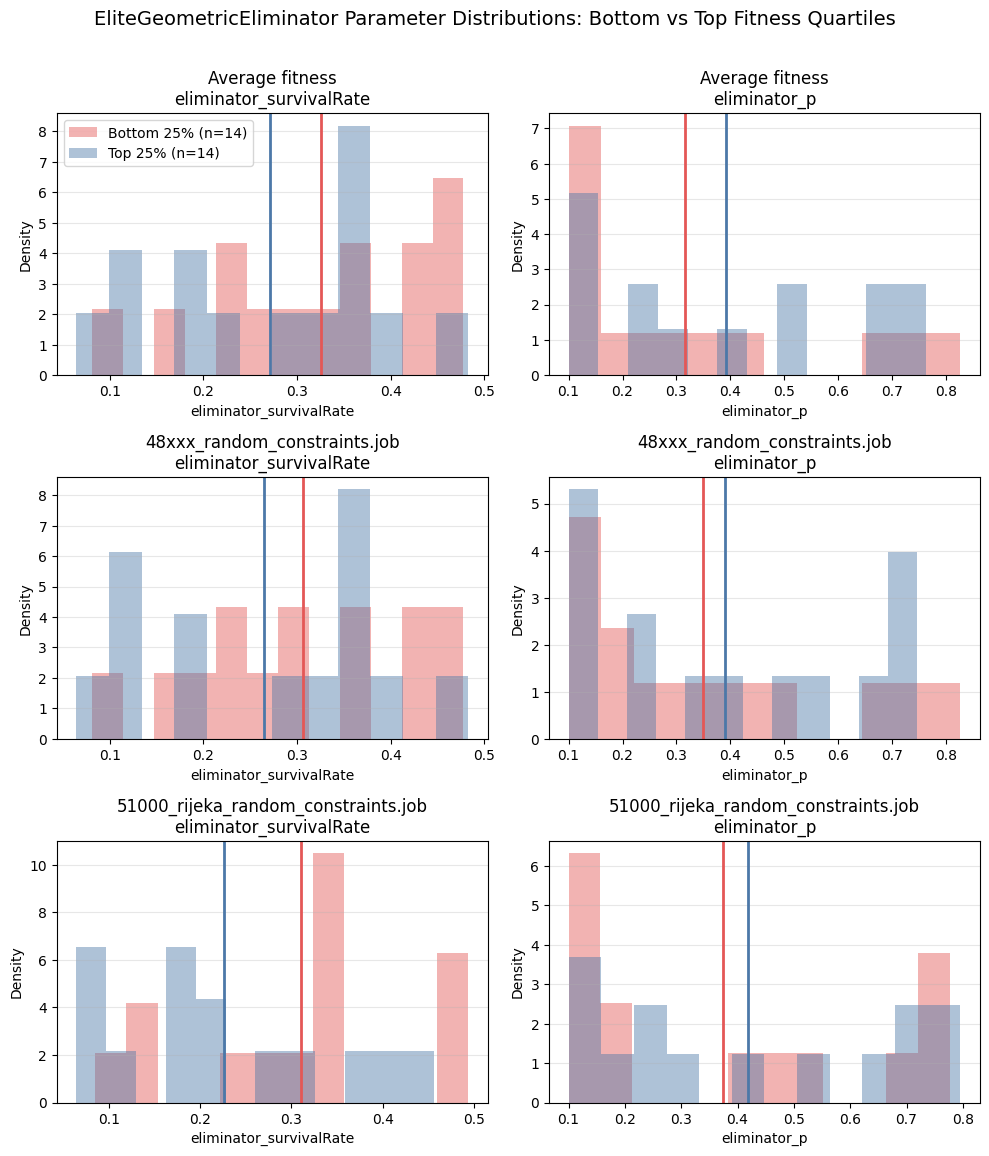

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
4,51000_rijeka_random_constraints.job,eliminator_survivalRate,0.310664,0.225661,-0.085003,-0.671765,0.341501,0.202246,14,14
0,Average fitness,eliminator_survivalRate,0.326048,0.271246,-0.054802,-0.445886,0.344350,0.296625,14,14
2,48xxx_random_constraints.job,eliminator_survivalRate,0.306056,0.264631,-0.041425,-0.331760,0.306804,0.296625,14,14
1,Average fitness,eliminator_p,0.315077,0.391237,0.076160,0.296773,0.212584,0.353139,14,14
5,51000_rijeka_random_constraints.job,eliminator_p,0.373555,0.418250,0.044694,0.164193,0.304827,0.353139,14,14
3,48xxx_random_constraints.job,eliminator_p,0.350052,0.390147,0.040095,0.159775,0.279305,0.353139,14,14


In [6]:
plot_categorical_top_bottom(
    analysis_df,
    ['eliminator_type'],
    'Eliminator Type Distribution: Bottom vs Top Fitness Quartiles',
)

eliminator_tables = top_bottom_categorical_summary(analysis_df, ['eliminator_type'])
for (target_label, feature_col), table in eliminator_tables.items():
    print(f'{target_label} - {feature_col}')
    display(table)

elite_only = analysis_df[analysis_df['eliminator_type'] == 'EliteEliminator'].copy()
geo_elite_only = analysis_df[analysis_df['eliminator_type'] == 'EliteGeometricEliminator'].copy()

plot_numeric_top_bottom(
    elite_only,
    ['eliminator_elitism'],
    'EliteEliminator Elitism Distribution: Bottom vs Top Fitness Quartiles',
)
display(top_bottom_numeric_summary(elite_only, ['eliminator_elitism']))

plot_numeric_top_bottom(
    geo_elite_only,
    ['eliminator_survivalRate', 'eliminator_p'],
    'EliteGeometricEliminator Parameter Distributions: Bottom vs Top Fitness Quartiles',
)
display(top_bottom_numeric_summary(geo_elite_only, ['eliminator_survivalRate', 'eliminator_p']))


## Crossover Settings

Raw crossover weights are converted to per-sample shares first. The derived pressure features combine weight share with how much row/column switching the selected crossover is expected to cause.

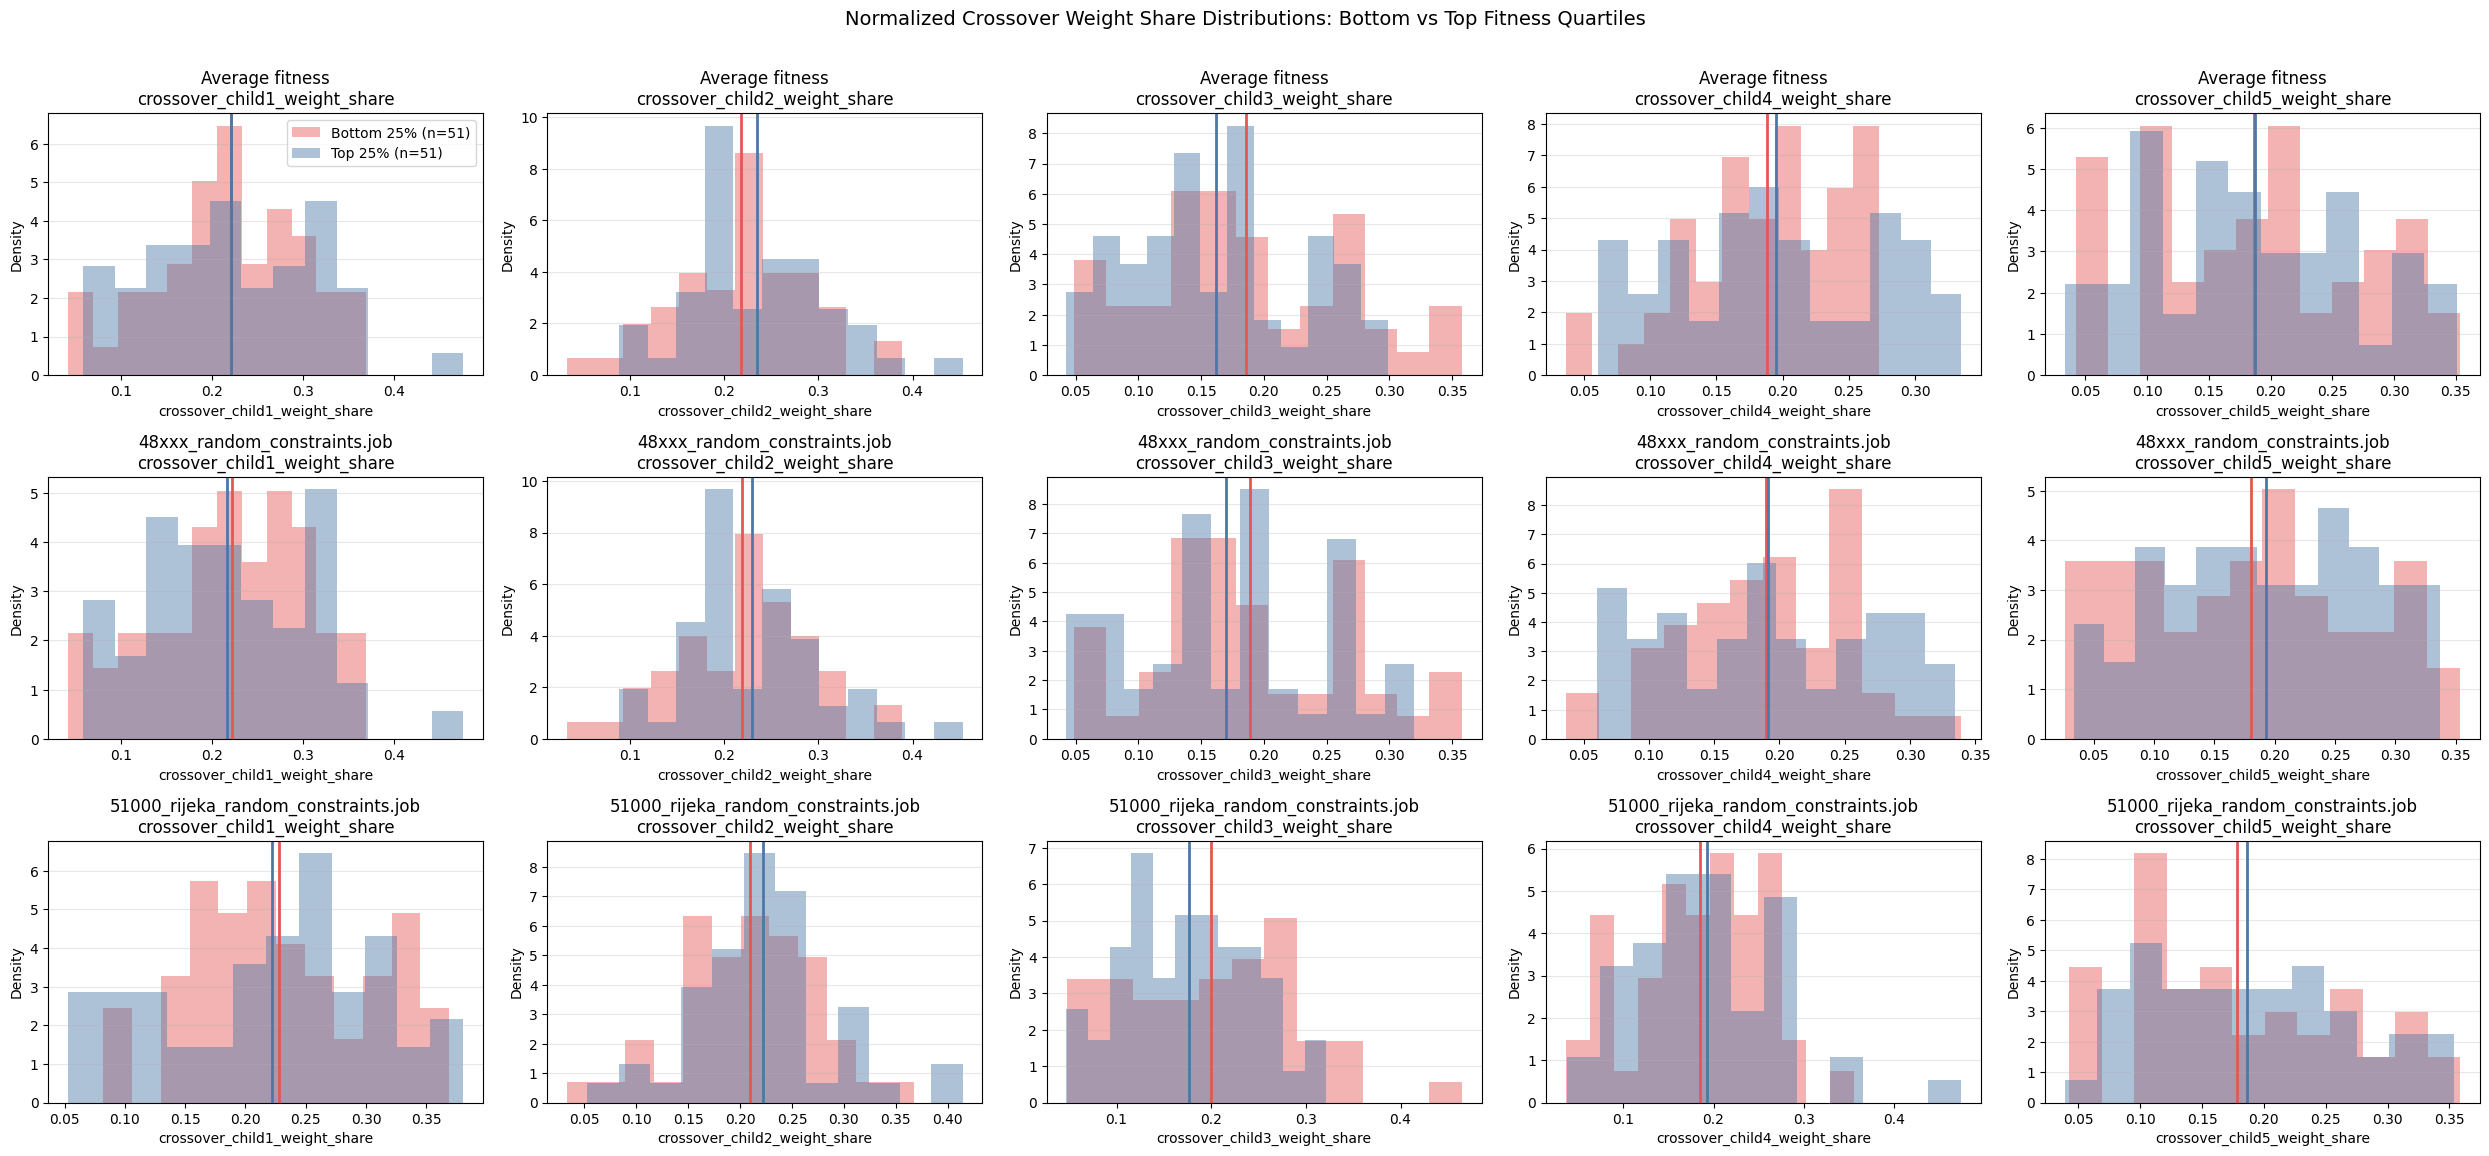

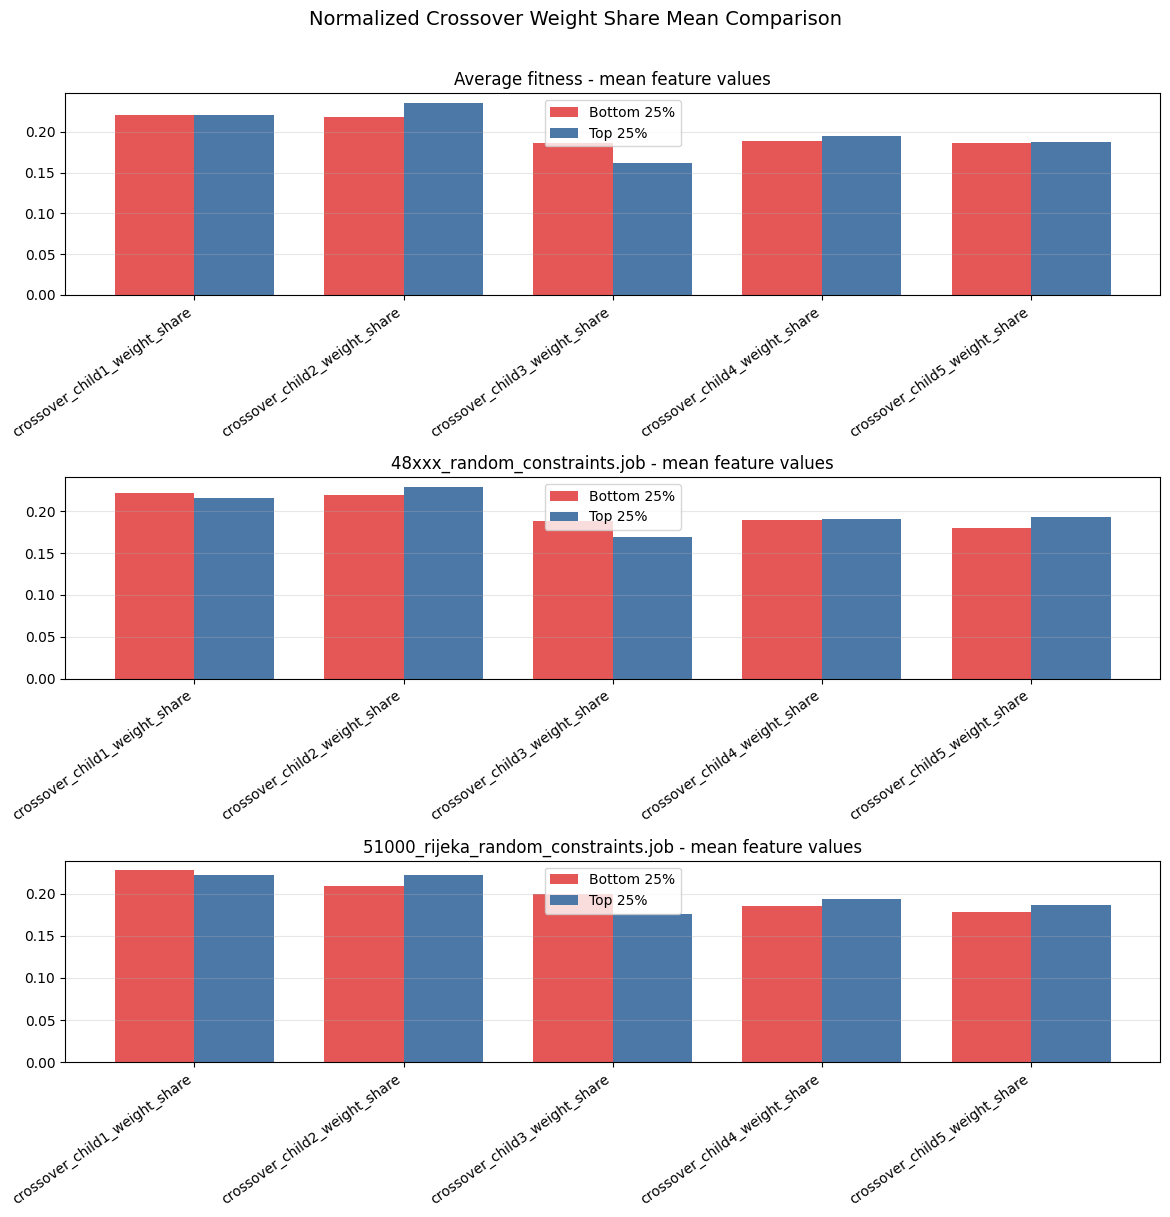

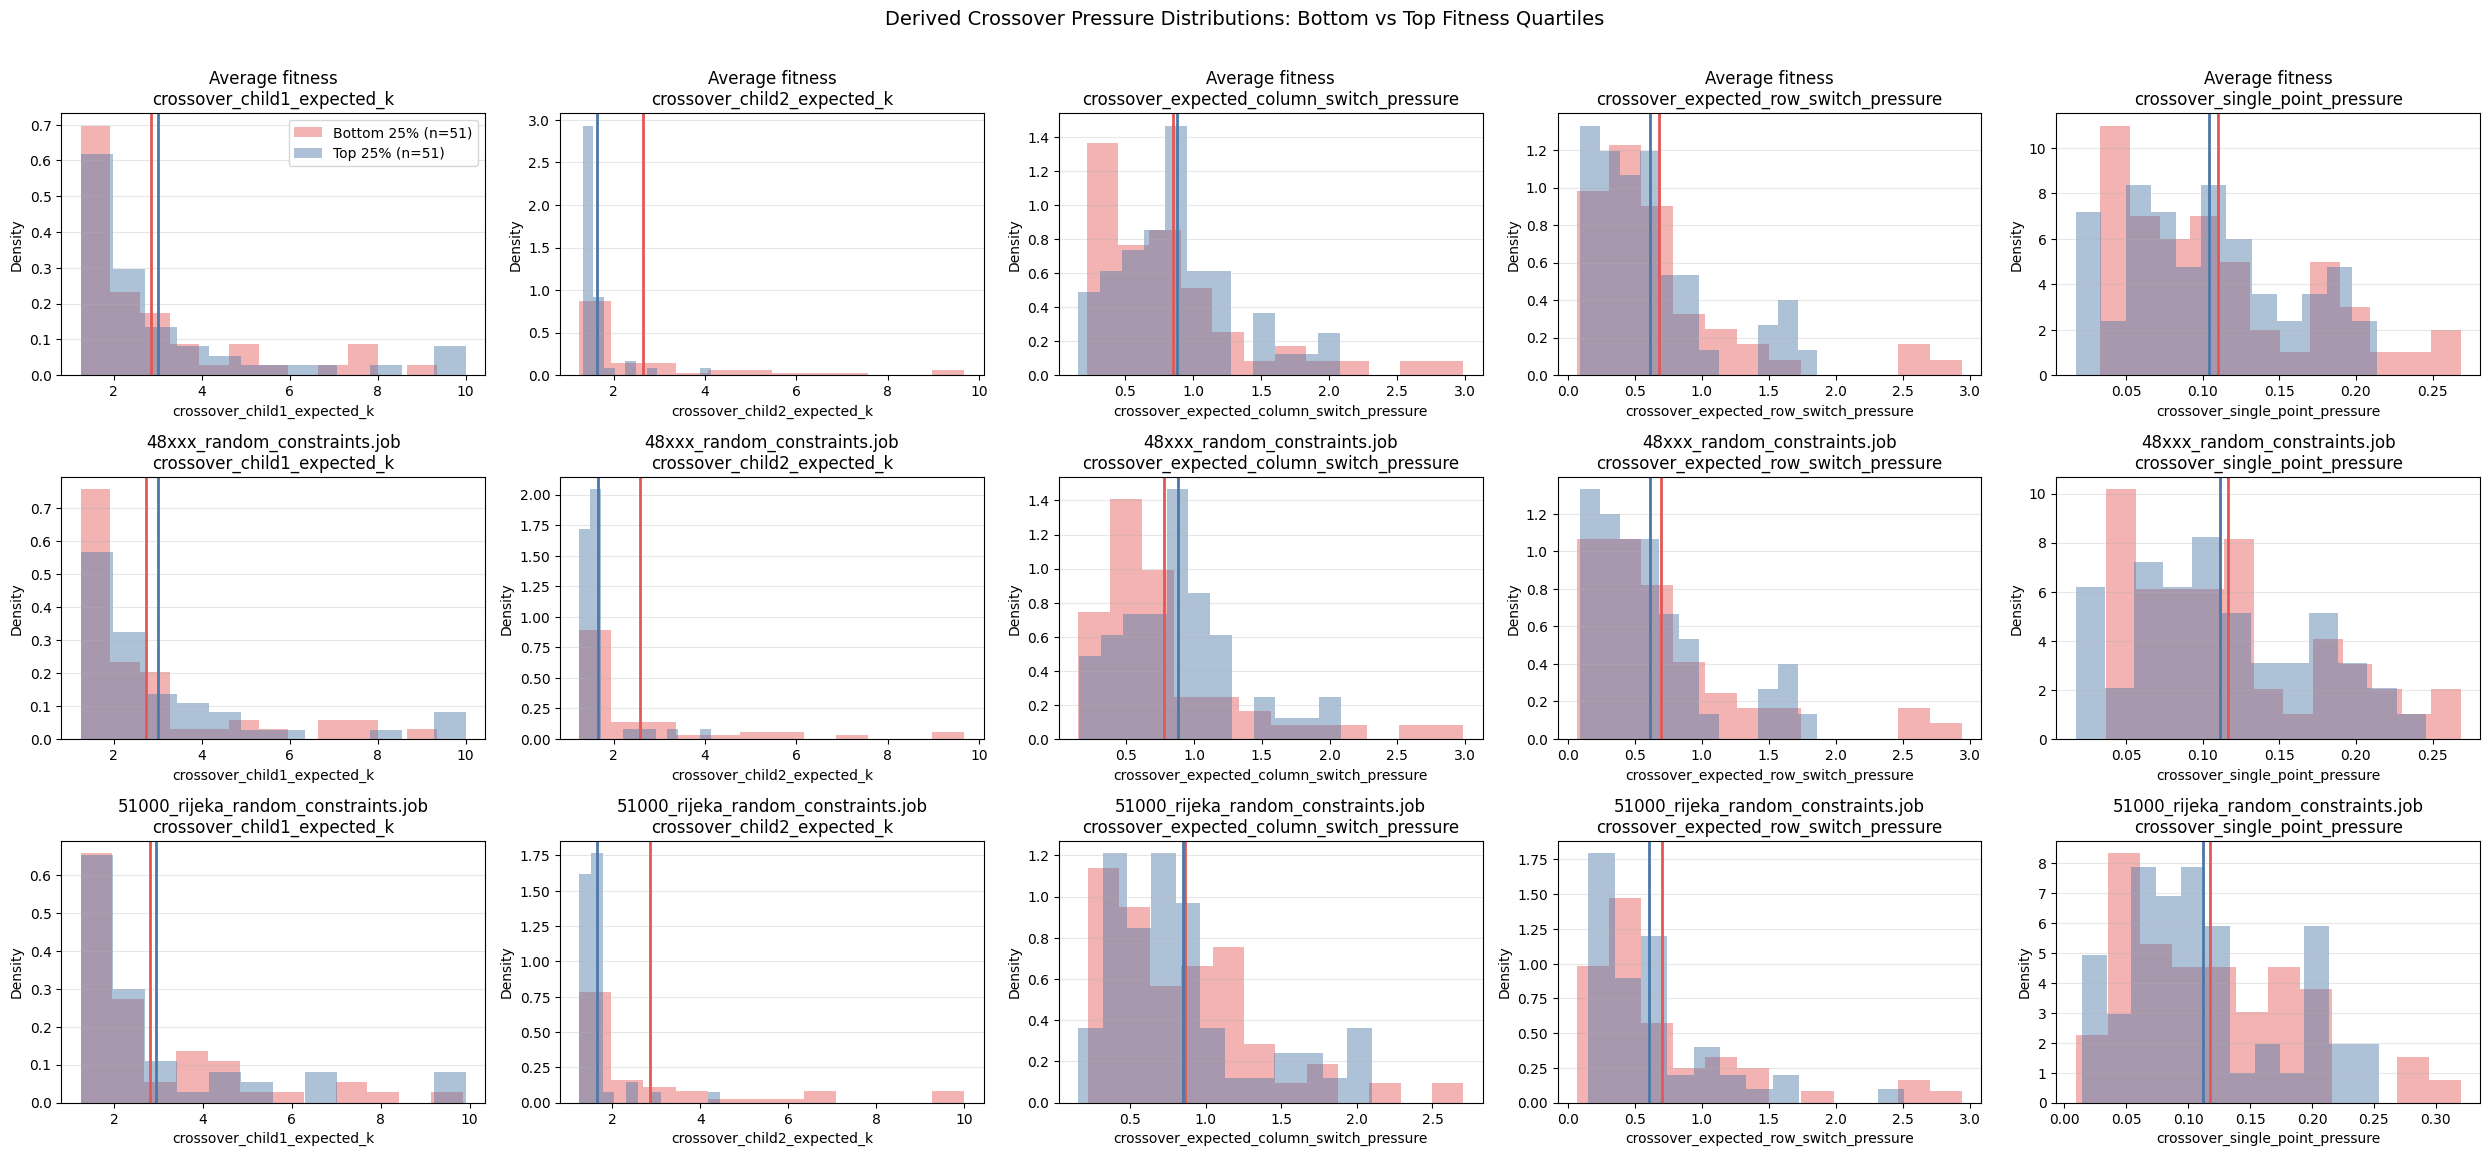

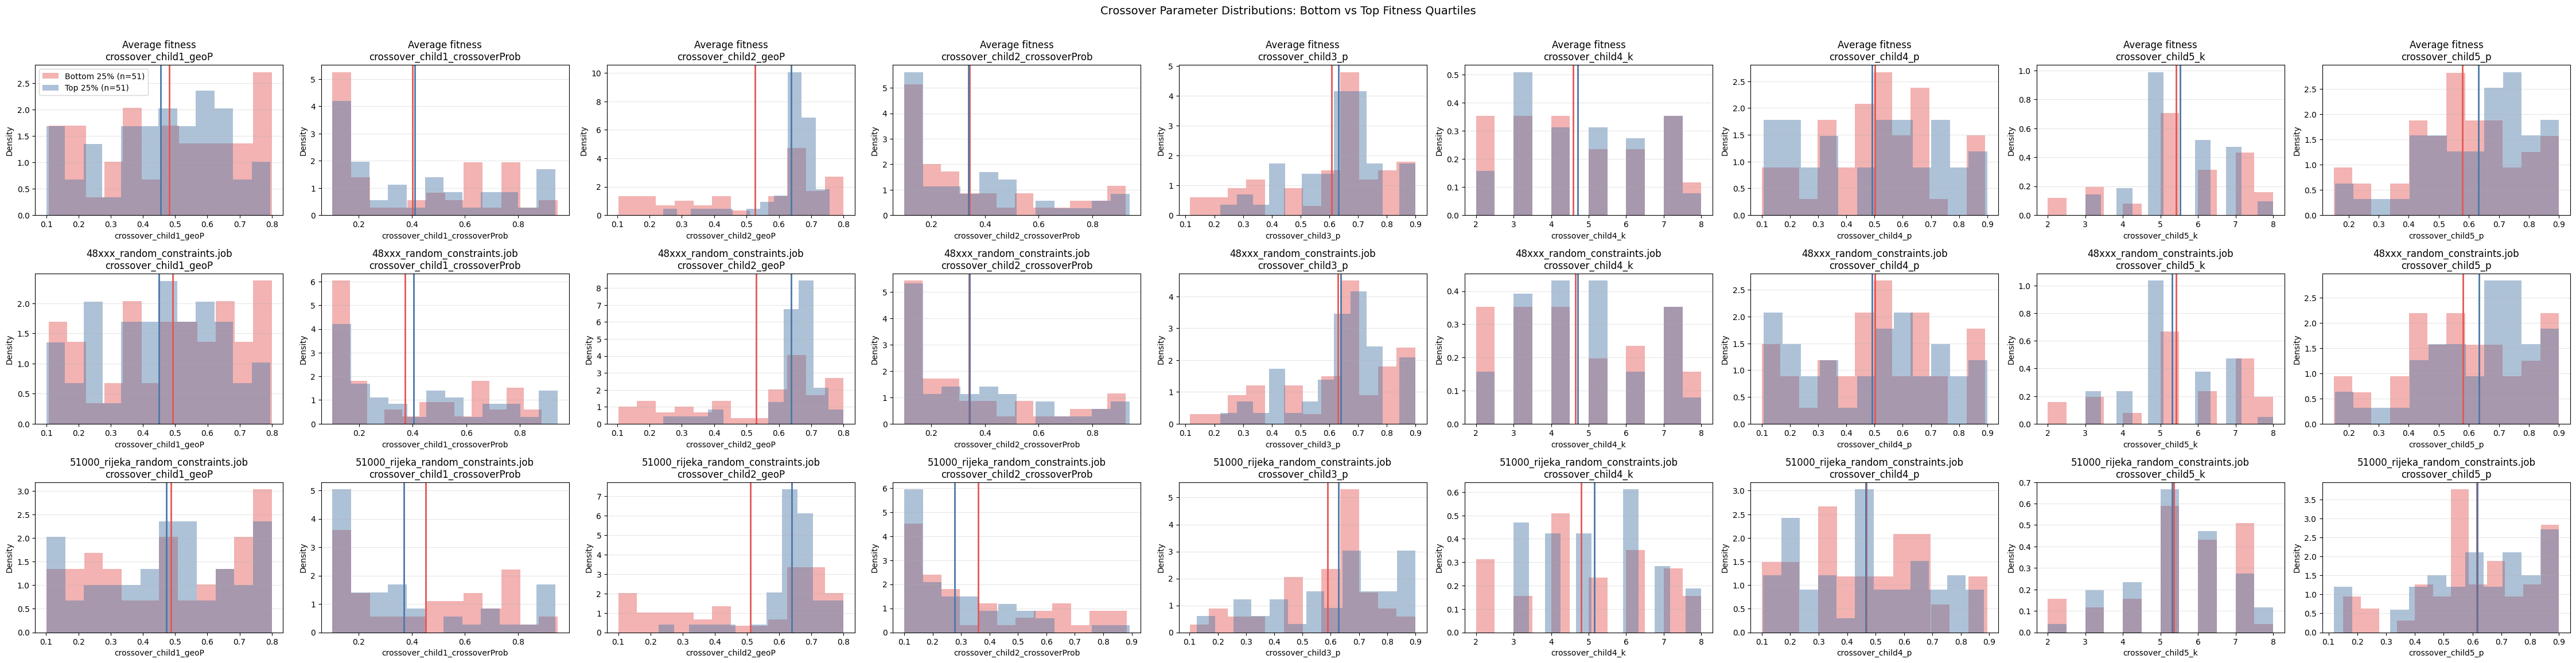

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
44,51000_rijeka_random_constraints.job,crossover_child2_expected_k,2.860509,1.641323,-1.219186,-0.721900,1.560633,1.538196,51,51
50,51000_rijeka_random_constraints.job,crossover_child2_geoP,0.510836,0.638084,0.127247,0.714827,0.640766,0.650112,51,51
6,Average fitness,crossover_child2_expected_k,2.636152,1.629675,-1.006477,-0.675592,1.581754,1.507089,51,51
12,Average fitness,crossover_child2_geoP,0.526793,0.638183,0.111390,0.660417,0.632210,0.663531,51,51
31,48xxx_random_constraints.job,crossover_child2_geoP,0.529848,0.637552,0.107705,0.638680,0.624313,0.666312,51,51
25,48xxx_random_constraints.job,crossover_child2_expected_k,2.580054,1.651550,-0.928504,-0.630785,1.601761,1.500798,51,51
51,51000_rijeka_random_constraints.job,crossover_child2_crossoverProb,0.360938,0.278366,-0.082572,-0.363212,0.266492,0.211175,51,51
2,Average fitness,crossover_child3_weight_share,0.186129,0.161705,-0.024423,-0.324388,0.174602,0.152439,51,51
49,51000_rijeka_random_constraints.job,crossover_child1_crossoverProb,0.451603,0.370817,-0.080786,-0.289880,0.480460,0.295334,51,51
18,Average fitness,crossover_child5_p,0.577748,0.631720,0.053972,0.286898,0.574813,0.666317,51,51


In [7]:
crossover_share_features = [f'crossover_child{i}_weight_share' for i in range(1, 6)]
crossover_param_features = [
    'crossover_child1_geoP',
    'crossover_child1_crossoverProb',
    'crossover_child2_geoP',
    'crossover_child2_crossoverProb',
    'crossover_child3_p',
    'crossover_child4_k',
    'crossover_child4_p',
    'crossover_child5_k',
    'crossover_child5_p',
]
crossover_derived_features = [
    'crossover_child1_expected_k',
    'crossover_child2_expected_k',
    'crossover_expected_column_switch_pressure',
    'crossover_expected_row_switch_pressure',
    'crossover_single_point_pressure',
]

plot_numeric_top_bottom(
    analysis_df,
    crossover_share_features,
    'Normalized Crossover Weight Share Distributions: Bottom vs Top Fitness Quartiles',
)
plot_top_bottom_mean_bars(
    analysis_df,
    crossover_share_features,
    'Normalized Crossover Weight Share Mean Comparison',
)

plot_numeric_top_bottom(
    analysis_df,
    crossover_derived_features,
    'Derived Crossover Pressure Distributions: Bottom vs Top Fitness Quartiles',
)
plot_numeric_top_bottom(
    analysis_df,
    crossover_param_features,
    'Crossover Parameter Distributions: Bottom vs Top Fitness Quartiles',
)

display(
    top_bottom_numeric_summary(
        analysis_df,
        [*crossover_share_features, *crossover_derived_features, *crossover_param_features],
    ).head(40)
)


## Mutator Settings

Mutator child weights are normalized before computing average mutations, average probability, and mutation intensity.

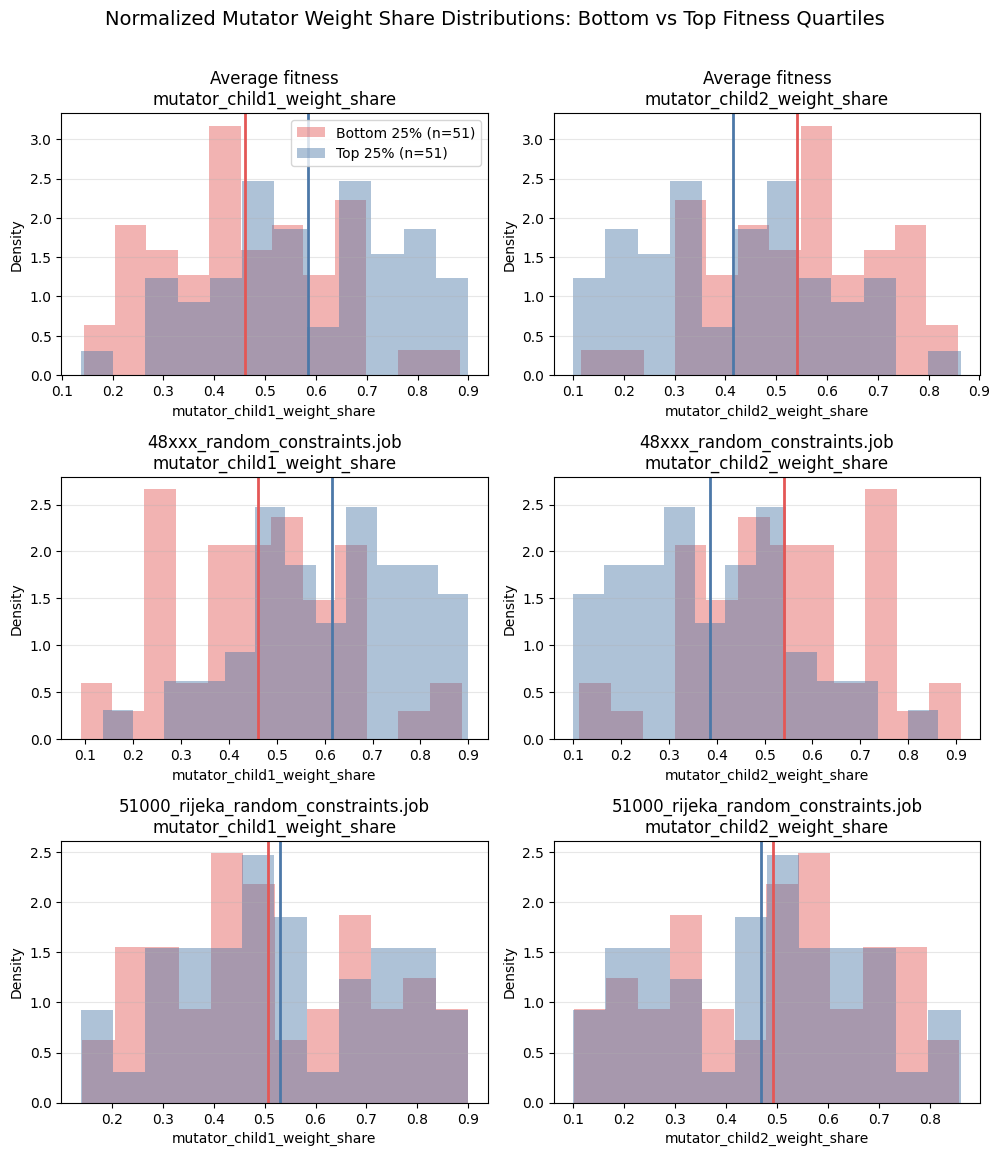

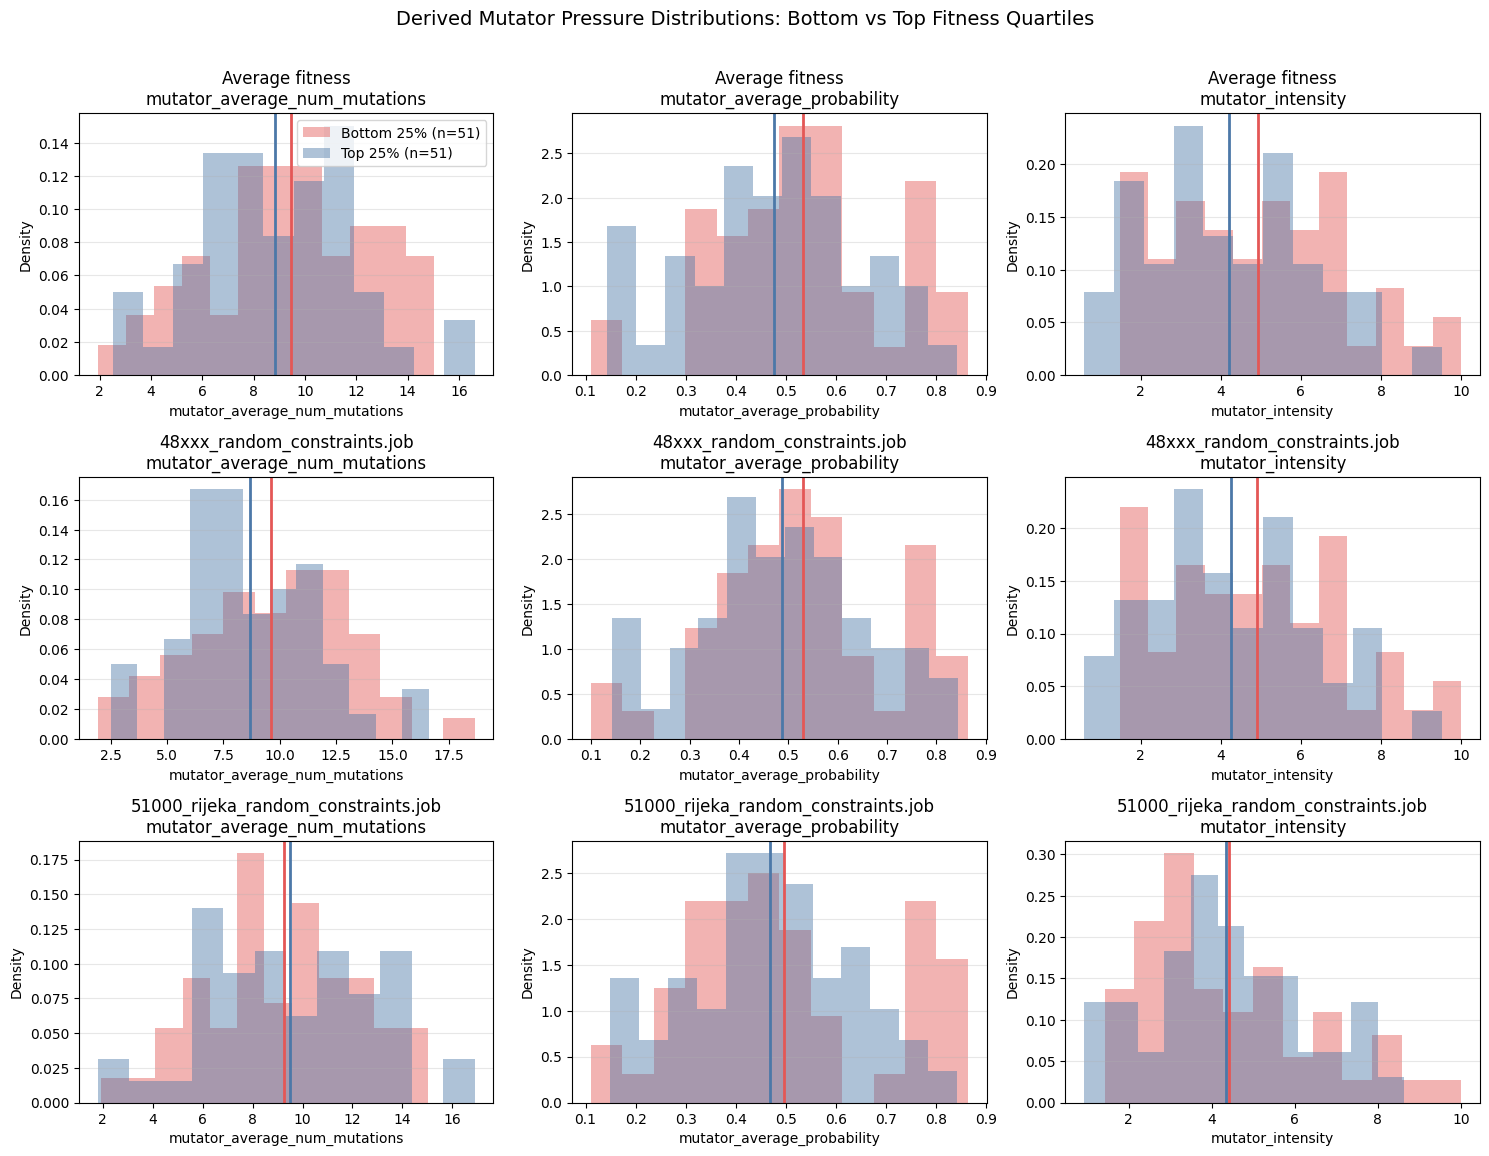

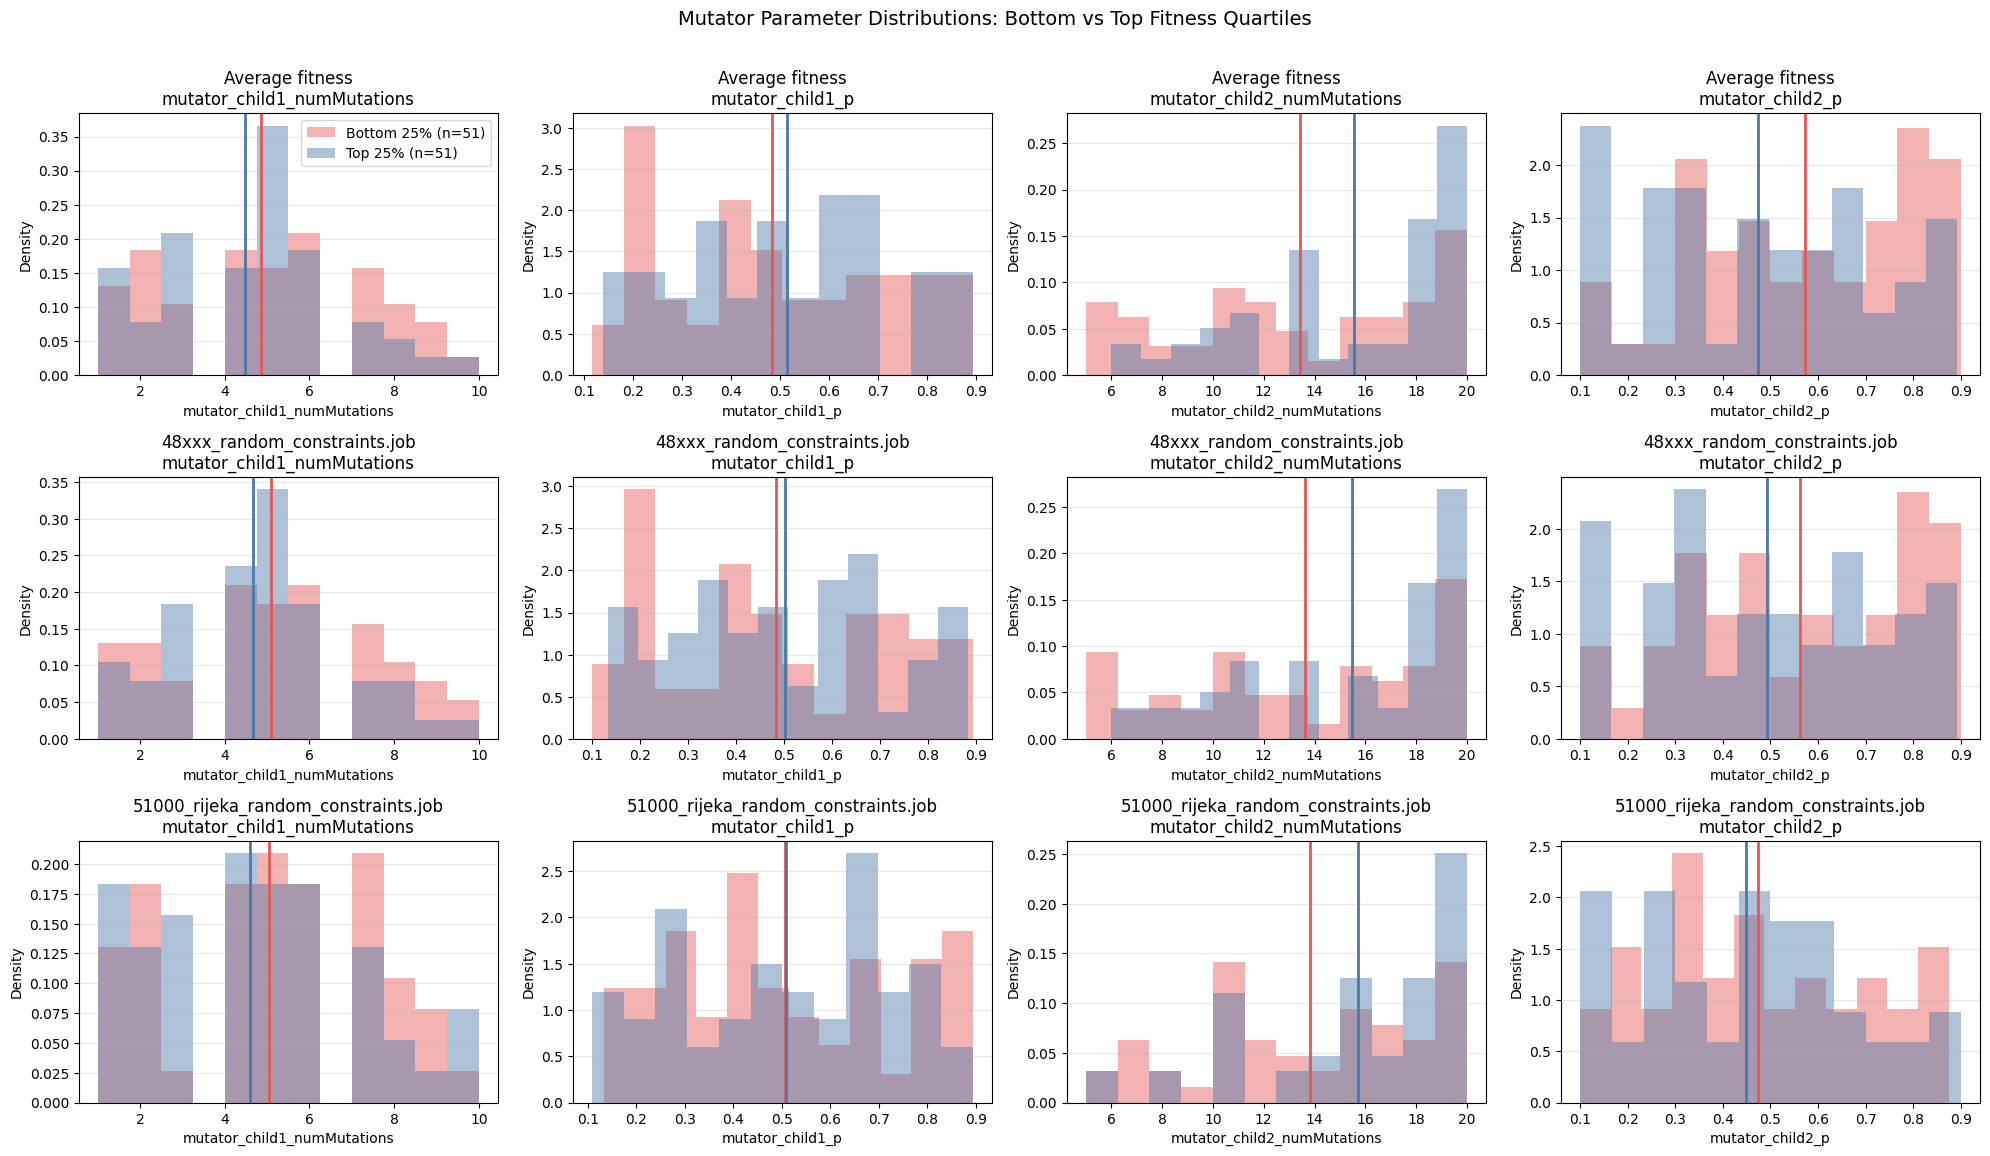

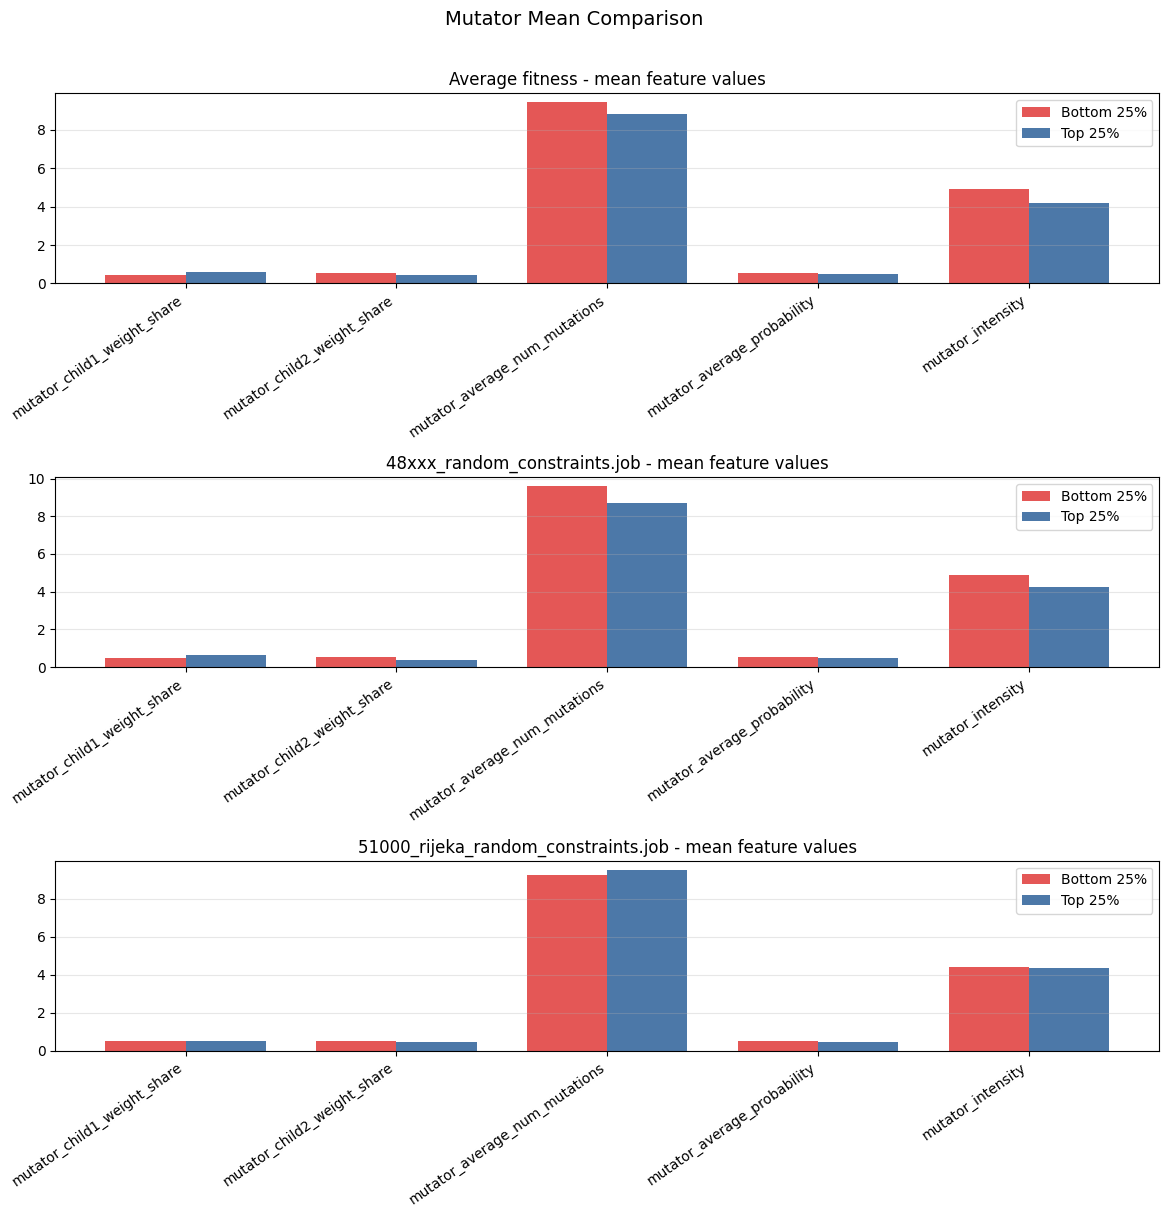

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
10,48xxx_random_constraints.job,mutator_child2_weight_share,0.539750,0.385187,-0.154563,-0.869078,0.561687,0.363330,51,51
9,48xxx_random_constraints.job,mutator_child1_weight_share,0.460250,0.614813,0.154563,0.869078,0.438313,0.636670,51,51
0,Average fitness,mutator_child1_weight_share,0.459506,0.583987,0.124481,0.705923,0.438313,0.575011,51,51
1,Average fitness,mutator_child2_weight_share,0.540494,0.416013,-0.124481,-0.705923,0.561687,0.424989,51,51
7,Average fitness,mutator_child2_numMutations,13.411765,15.568627,2.156863,0.475114,13.000000,18.000000,51,51
25,51000_rijeka_random_constraints.job,mutator_child2_numMutations,13.803922,15.725490,1.921569,0.455430,14.000000,17.000000,51,51
8,Average fitness,mutator_child2_p,0.572268,0.474776,-0.097492,-0.407570,0.585857,0.476970,51,51
16,48xxx_random_constraints.job,mutator_child2_numMutations,13.607843,15.470588,1.862745,0.399244,14.000000,18.000000,51,51
4,Average fitness,mutator_intensity,4.939846,4.204976,-0.734871,-0.345108,4.970951,3.984242,51,51
3,Average fitness,mutator_average_probability,0.534139,0.477103,-0.057037,-0.334392,0.541204,0.489588,51,51


In [8]:
mutator_share_features = ['mutator_child1_weight_share', 'mutator_child2_weight_share']
mutator_derived_features = [
    'mutator_average_num_mutations',
    'mutator_average_probability',
    'mutator_intensity',
]
mutator_param_features = [
    'mutator_child1_numMutations',
    'mutator_child1_p',
    'mutator_child2_numMutations',
    'mutator_child2_p',
]

plot_numeric_top_bottom(
    analysis_df,
    mutator_share_features,
    'Normalized Mutator Weight Share Distributions: Bottom vs Top Fitness Quartiles',
)
plot_numeric_top_bottom(
    analysis_df,
    mutator_derived_features,
    'Derived Mutator Pressure Distributions: Bottom vs Top Fitness Quartiles',
)
plot_numeric_top_bottom(
    analysis_df,
    mutator_param_features,
    'Mutator Parameter Distributions: Bottom vs Top Fitness Quartiles',
)
plot_top_bottom_mean_bars(
    analysis_df,
    [*mutator_share_features, *mutator_derived_features],
    'Mutator Mean Comparison',
)

display(
    top_bottom_numeric_summary(
        analysis_df,
        [*mutator_share_features, *mutator_derived_features, *mutator_param_features],
    ).head(40)
)


## Cluster Settings

The rounded-distance categorical view can expose preferred bands, while the raw numeric view keeps the continuous distribution visible.

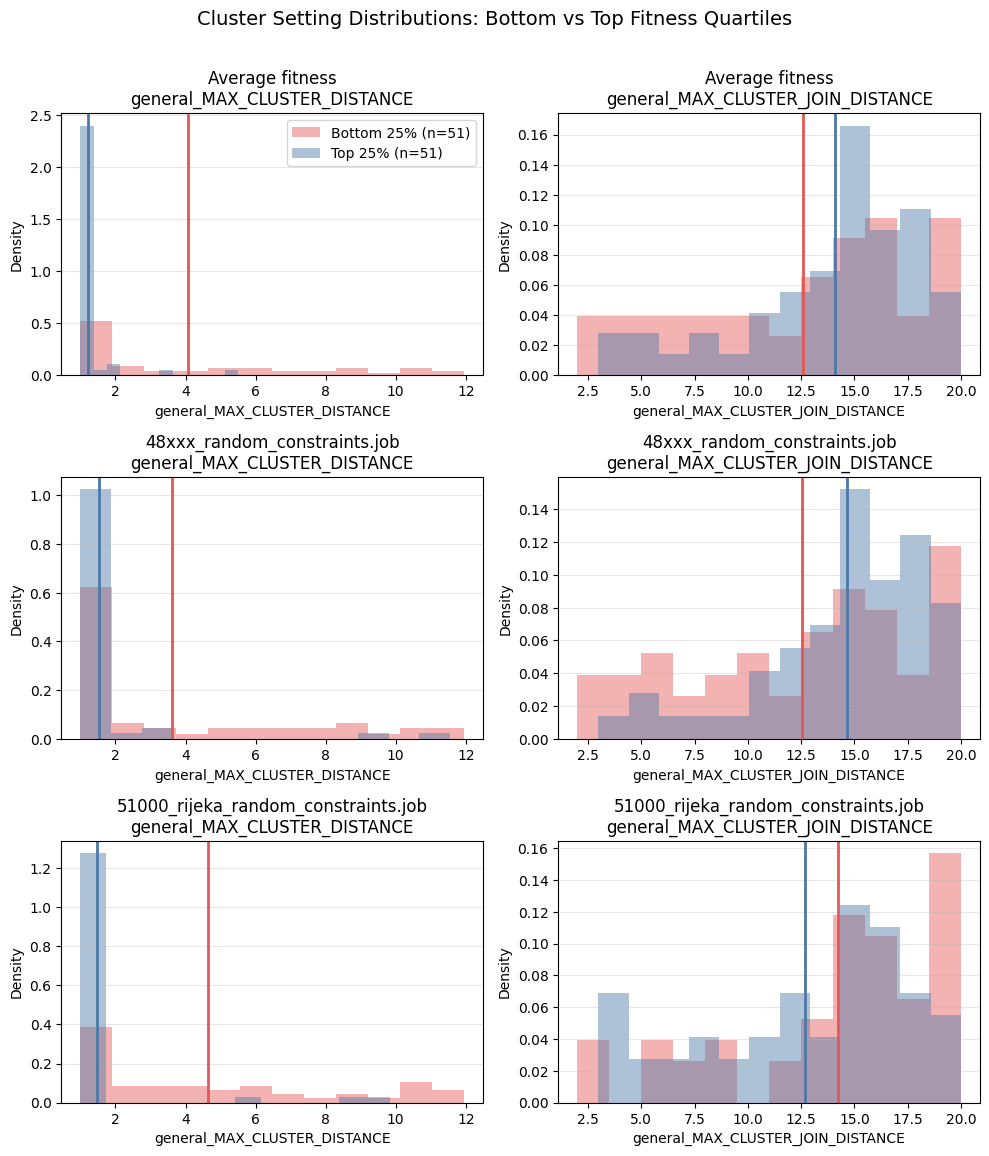

,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
0,Average fitness,general_MAX_CLUSTER_DISTANCE,4.077110,1.222295,-2.854815,-1.110974,2.139882,1.000000,51,51
4,51000_rijeka_random_constraints.job,general_MAX_CLUSTER_DISTANCE,4.653621,1.483363,-3.170258,-1.107815,3.446418,1.000000,51,51
2,48xxx_random_constraints.job,general_MAX_CLUSTER_DISTANCE,3.609653,1.530867,-2.078786,-0.742939,1.480568,1.000000,51,51
3,48xxx_random_constraints.job,general_MAX_CLUSTER_JOIN_DISTANCE,12.549074,14.641003,2.091928,0.442758,13.605492,15.441260,51,51
1,Average fitness,general_MAX_CLUSTER_JOIN_DISTANCE,12.604483,14.087430,1.482947,0.309910,14.169109,15.099063,51,51
5,51000_rijeka_random_constraints.job,general_MAX_CLUSTER_JOIN_DISTANCE,14.224965,12.680907,-1.544058,-0.309460,15.397035,14.354295,51,51


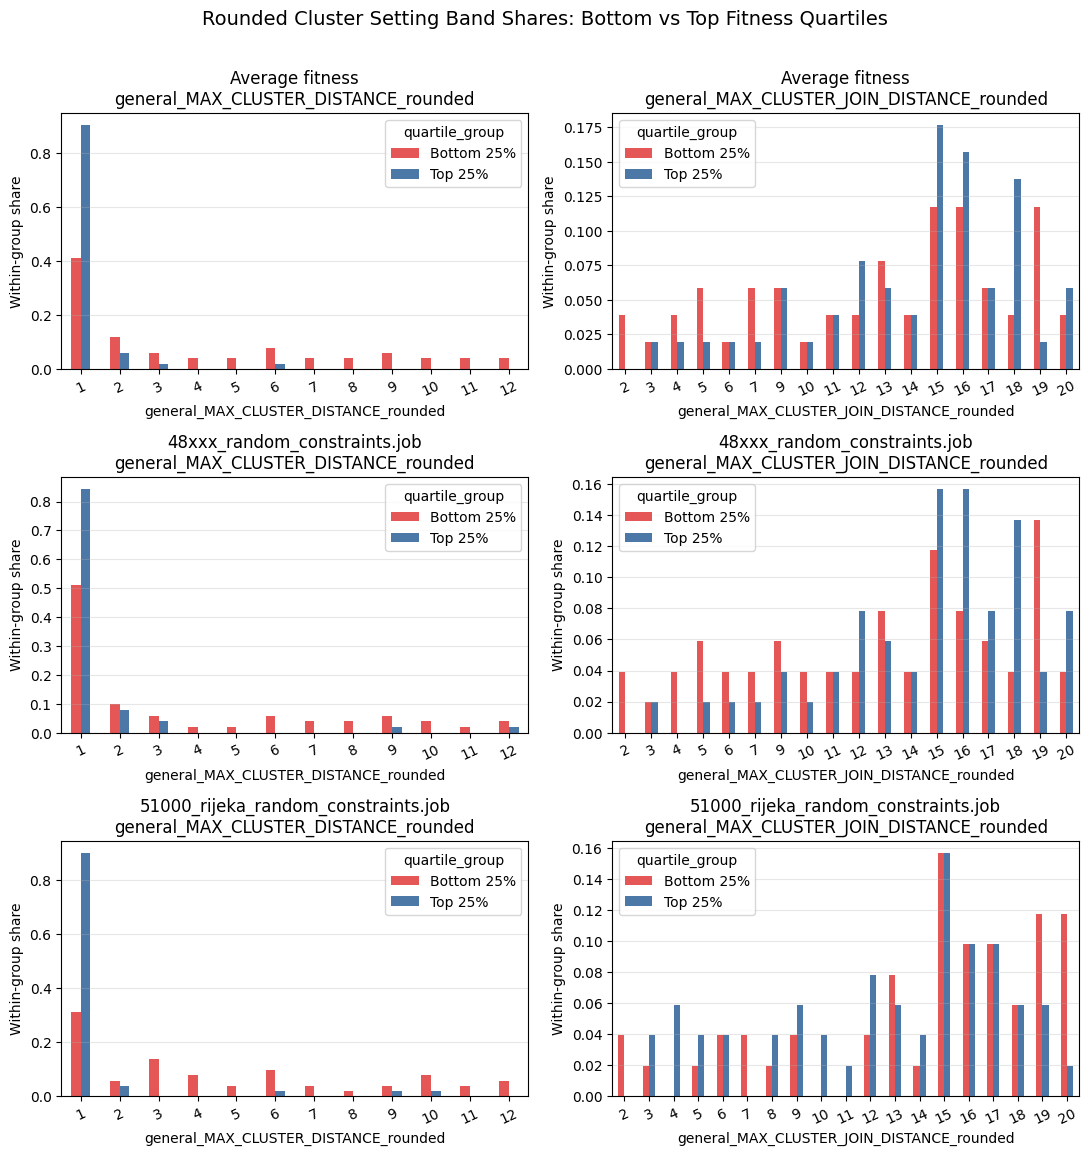

Average fitness - general_MAX_CLUSTER_DISTANCE_rounded


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
general_MAX_CLUSTER_DISTANCE_rounded,,,
1,0.411765,0.901961,0.490196
2,0.117647,0.058824,-0.058824
9,0.058824,0.000000,-0.058824
6,0.078431,0.019608,-0.058824
4,0.039216,0.000000,-0.039216
3,0.058824,0.019608,-0.039216
7,0.039216,0.000000,-0.039216
5,0.039216,0.000000,-0.039216
8,0.039216,0.000000,-0.039216


Average fitness - general_MAX_CLUSTER_JOIN_DISTANCE_rounded


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
general_MAX_CLUSTER_JOIN_DISTANCE_rounded,,,
18,0.039216,0.137255,0.098039
19,0.117647,0.019608,-0.098039
15,0.117647,0.176471,0.058824
2,0.039216,0.000000,-0.039216
16,0.117647,0.156863,0.039216
5,0.058824,0.019608,-0.039216
12,0.039216,0.078431,0.039216
7,0.058824,0.019608,-0.039216
20,0.039216,0.058824,0.019608


48xxx_random_constraints.job - general_MAX_CLUSTER_DISTANCE_rounded


...

quartile_group,Bottom 25%,Top 25%,top_minus_bottom
general_MAX_CLUSTER_JOIN_DISTANCE_rounded,,,
19,0.137255,0.039216,-0.098039
18,0.039216,0.137255,0.098039
16,0.078431,0.156863,0.078431
2,0.039216,0.000000,-0.039216
15,0.117647,0.156863,0.039216
4,0.039216,0.000000,-0.039216
12,0.039216,0.078431,0.039216
5,0.058824,0.019608,-0.039216
20,0.039216,0.078431,0.039216


51000_rijeka_random_constraints.job - general_MAX_CLUSTER_DISTANCE_rounded


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
general_MAX_CLUSTER_DISTANCE_rounded,,,
1,0.313725,0.901961,0.588235
3,0.137255,0.000000,-0.137255
4,0.078431,0.000000,-0.078431
6,0.098039,0.019608,-0.078431
12,0.058824,0.000000,-0.058824
10,0.078431,0.019608,-0.058824
11,0.039216,0.000000,-0.039216
5,0.039216,0.000000,-0.039216
7,0.039216,0.000000,-0.039216


51000_rijeka_random_constraints.job - general_MAX_CLUSTER_JOIN_DISTANCE_rounded


quartile_group,Bottom 25%,Top 25%,top_minus_bottom
general_MAX_CLUSTER_JOIN_DISTANCE_rounded,,,
20,0.117647,0.019608,-0.098039
19,0.117647,0.058824,-0.058824
4,0.000000,0.058824,0.058824
12,0.039216,0.078431,0.039216
2,0.039216,0.000000,-0.039216
7,0.039216,0.000000,-0.039216
10,0.000000,0.039216,0.039216
3,0.019608,0.039216,0.019608
8,0.019608,0.039216,0.019608


In [9]:
cluster_features = ['general_MAX_CLUSTER_DISTANCE', 'general_MAX_CLUSTER_JOIN_DISTANCE']
cluster_rounded_features = [f'{col}_rounded' for col in cluster_features]

plot_numeric_top_bottom(
    analysis_df,
    cluster_features,
    'Cluster Setting Distributions: Bottom vs Top Fitness Quartiles',
)
display(top_bottom_numeric_summary(analysis_df, cluster_features))

plot_categorical_top_bottom(
    analysis_df,
    cluster_rounded_features,
    'Rounded Cluster Setting Band Shares: Bottom vs Top Fitness Quartiles',
)
cluster_tables = top_bottom_categorical_summary(analysis_df, cluster_rounded_features)
for (target_label, feature_col), table in cluster_tables.items():
    print(f'{target_label} - {feature_col}')
    display(table.head(15))


## Overall Effect-Size Scoreboard

This table ranks all engineered numeric features by absolute standardized difference between top and bottom quartiles. It is a compact way to spot the parameters that separate good and bad runs most strongly.

In [10]:
scoreboard_features = [
    *ga_budget_features,
    'selection_tournamentSize',
    'eliminator_elitism',
    'eliminator_survivalRate',
    'eliminator_p',
    *mutator_share_features,
    *mutator_derived_features,
    *mutator_param_features,
    *crossover_share_features,
    *crossover_derived_features,
    *crossover_param_features,
    *cluster_features,
]

scoreboard = top_bottom_numeric_summary(analysis_df, scoreboard_features)
for target_label, target_scoreboard in scoreboard.groupby('fitness_target'):
    print(target_label)
    display(target_scoreboard.head(20))


48xxx_random_constraints.job


,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
51,48xxx_random_constraints.job,mutator_child2_weight_share,0.539750,0.385187,-0.154563,-0.869078,0.561687,0.363330,51,51
50,48xxx_random_constraints.job,mutator_child1_weight_share,0.460250,0.614813,0.154563,0.869078,0.438313,0.636670,51,51
78,48xxx_random_constraints.job,general_MAX_CLUSTER_DISTANCE,3.609653,1.530867,-2.078786,-0.742939,1.480568,1.000000,51,51
71,48xxx_random_constraints.job,crossover_child2_geoP,0.529848,0.637552,0.107705,0.638680,0.624313,0.666312,51,51
65,48xxx_random_constraints.job,crossover_child2_expected_k,2.580054,1.651550,-0.928504,-0.630785,1.601761,1.500798,51,51
45,48xxx_random_constraints.job,new_chromosome_rate,0.064439,0.025008,-0.039431,-0.466830,0.020000,0.020000,51,51
79,48xxx_random_constraints.job,general_MAX_CLUSTER_JOIN_DISTANCE,12.549074,14.641003,2.091928,0.442758,13.605492,15.441260,51,51
57,48xxx_random_constraints.job,mutator_child2_numMutations,13.607843,15.470588,1.862745,0.399244,14.000000,18.000000,51,51
47,48xxx_random_constraints.job,eliminator_elitism,8.137255,6.078431,-2.058824,-0.341541,7.000000,4.000000,51,51
44,48xxx_random_constraints.job,total_new_chromosomes,41941.176471,56107.843137,14166.666667,0.310652,32000.000000,42000.000000,51,51


51000_rijeka_random_constraints.job


,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
118,51000_rijeka_random_constraints.job,general_MAX_CLUSTER_DISTANCE,4.653621,1.483363,-3.170258,-1.107815,3.446418,1.000000,51,51
105,51000_rijeka_random_constraints.job,crossover_child2_expected_k,2.860509,1.641323,-1.219186,-0.721900,1.560633,1.538196,51,51
111,51000_rijeka_random_constraints.job,crossover_child2_geoP,0.510836,0.638084,0.127247,0.714827,0.640766,0.650112,51,51
97,51000_rijeka_random_constraints.job,mutator_child2_numMutations,13.803922,15.725490,1.921569,0.455430,14.000000,17.000000,51,51
112,51000_rijeka_random_constraints.job,crossover_child2_crossoverProb,0.360938,0.278366,-0.082572,-0.363212,0.266492,0.211175,51,51
88,51000_rijeka_random_constraints.job,eliminator_survivalRate,0.291202,0.251303,-0.039900,-0.327419,0.290962,0.226826,51,51
119,51000_rijeka_random_constraints.job,general_MAX_CLUSTER_JOIN_DISTANCE,14.224965,12.680907,-1.544058,-0.309460,15.397035,14.354295,51,51
110,51000_rijeka_random_constraints.job,crossover_child1_crossoverProb,0.451603,0.370817,-0.080786,-0.289880,0.480460,0.295334,51,51
101,51000_rijeka_random_constraints.job,crossover_child3_weight_share,0.199322,0.176096,-0.023226,-0.286759,0.194267,0.181586,51,51
86,51000_rijeka_random_constraints.job,selection_tournamentSize,3.941176,4.294118,0.352941,0.283113,4.000000,5.000000,51,51


Average fitness


,fitness_target,feature,bottom_mean,top_mean,mean_delta,cohen_d,bottom_median,top_median,n_bottom,n_top
38,Average fitness,general_MAX_CLUSTER_DISTANCE,4.077110,1.222295,-2.854815,-1.110974,2.139882,1.000000,51,51
10,Average fitness,mutator_child1_weight_share,0.459506,0.583987,0.124481,0.705923,0.438313,0.575011,51,51
11,Average fitness,mutator_child2_weight_share,0.540494,0.416013,-0.124481,-0.705923,0.561687,0.424989,51,51
25,Average fitness,crossover_child2_expected_k,2.636152,1.629675,-1.006477,-0.675592,1.581754,1.507089,51,51
31,Average fitness,crossover_child2_geoP,0.526793,0.638183,0.111390,0.660417,0.632210,0.663531,51,51
5,Average fitness,new_chromosome_rate,0.057753,0.019659,-0.038094,-0.508307,0.020000,0.020000,51,51
17,Average fitness,mutator_child2_numMutations,13.411765,15.568627,2.156863,0.475114,13.000000,18.000000,51,51
18,Average fitness,mutator_child2_p,0.572268,0.474776,-0.097492,-0.407570,0.585857,0.476970,51,51
4,Average fitness,total_new_chromosomes,39303.921569,56715.686275,17411.764706,0.385662,32000.000000,40000.000000,51,51
2,Average fitness,newChromosomes,15.137255,18.372549,3.235294,0.371997,16.000000,20.000000,51,51


## Random-Forest Classifier SHAP: Top vs Bottom Quartile

This is a better fit for the question than regression SHAP: train a classifier to distinguish top-quartile runs from bottom-quartile runs, then inspect which features push runs toward the top class.

d:\Coding\FAKS\Mentor\working-sundays\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Average fitness: top-vs-bottom classifier train AUC = 0.988 (102 rows)


,mean_abs_shap_for_top_class
general_MAX_CLUSTER_DISTANCE,0.080151
mutator_child2_weight_share,0.027146
mutator_child1_weight_share,0.026024
crossover_child2_expected_k,0.021360
crossover_child2_geoP,0.020873
mutator_child2_p,0.018315
search_effort,0.013919
crossover_child5_p,0.011737
eliminator_p,0.011475
populationSize,0.011402


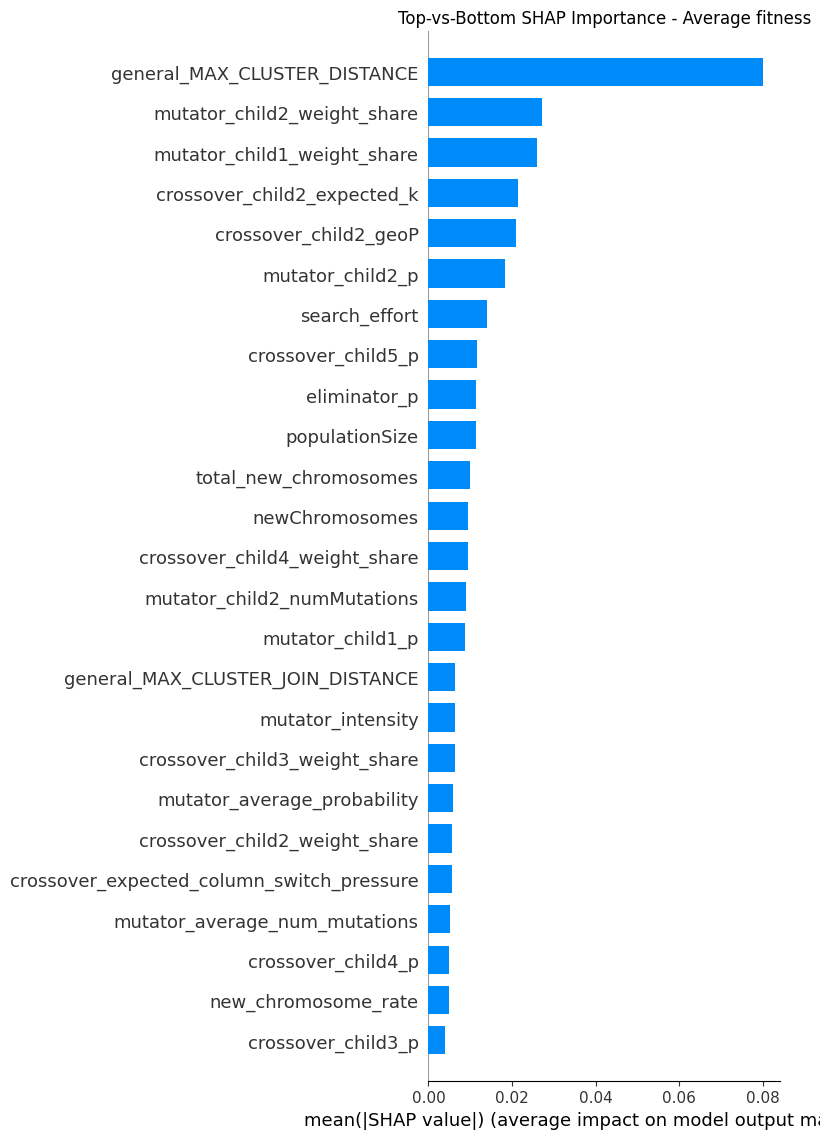

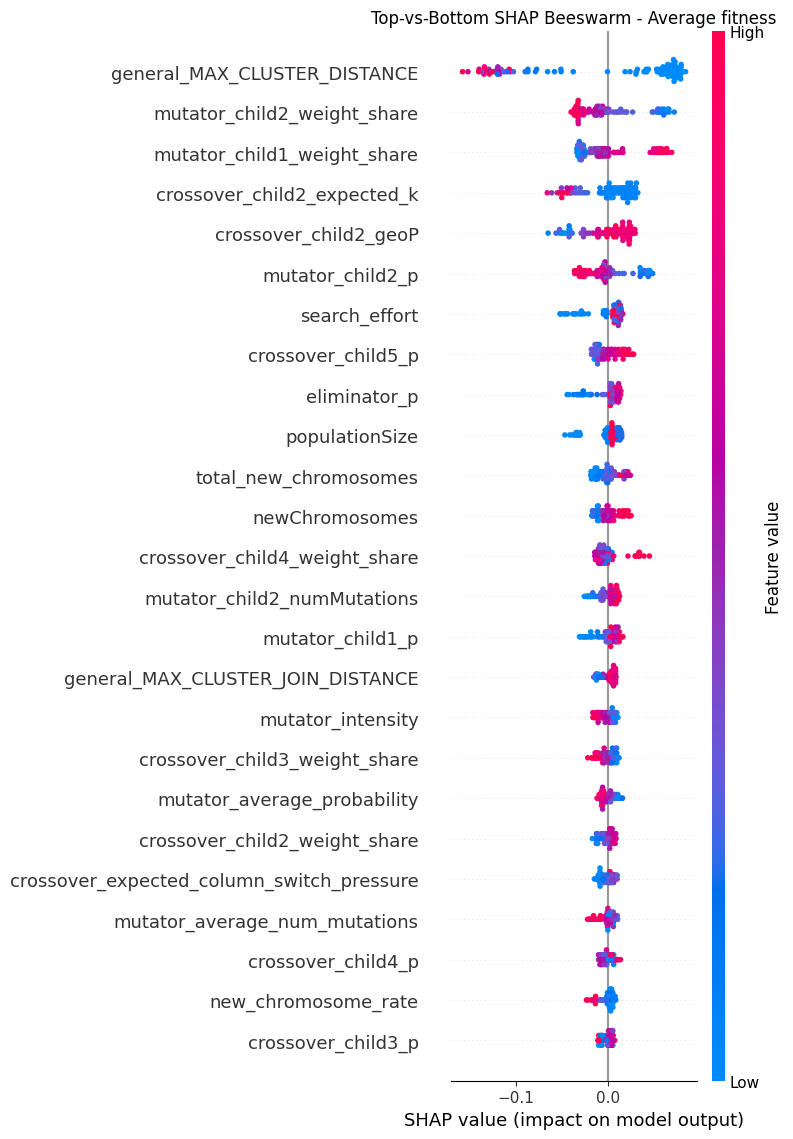

48xxx_random_constraints.job: top-vs-bottom classifier train AUC = 0.995 (102 rows)


,mean_abs_shap_for_top_class
mutator_child2_weight_share,0.040808
mutator_child1_weight_share,0.037922
general_MAX_CLUSTER_DISTANCE,0.036479
crossover_child2_geoP,0.027416
crossover_child2_expected_k,0.025356
general_MAX_CLUSTER_JOIN_DISTANCE,0.017777
crossover_expected_column_switch_pressure,0.015631
search_effort,0.012388
crossover_child5_p,0.010542
populationSize,0.010337


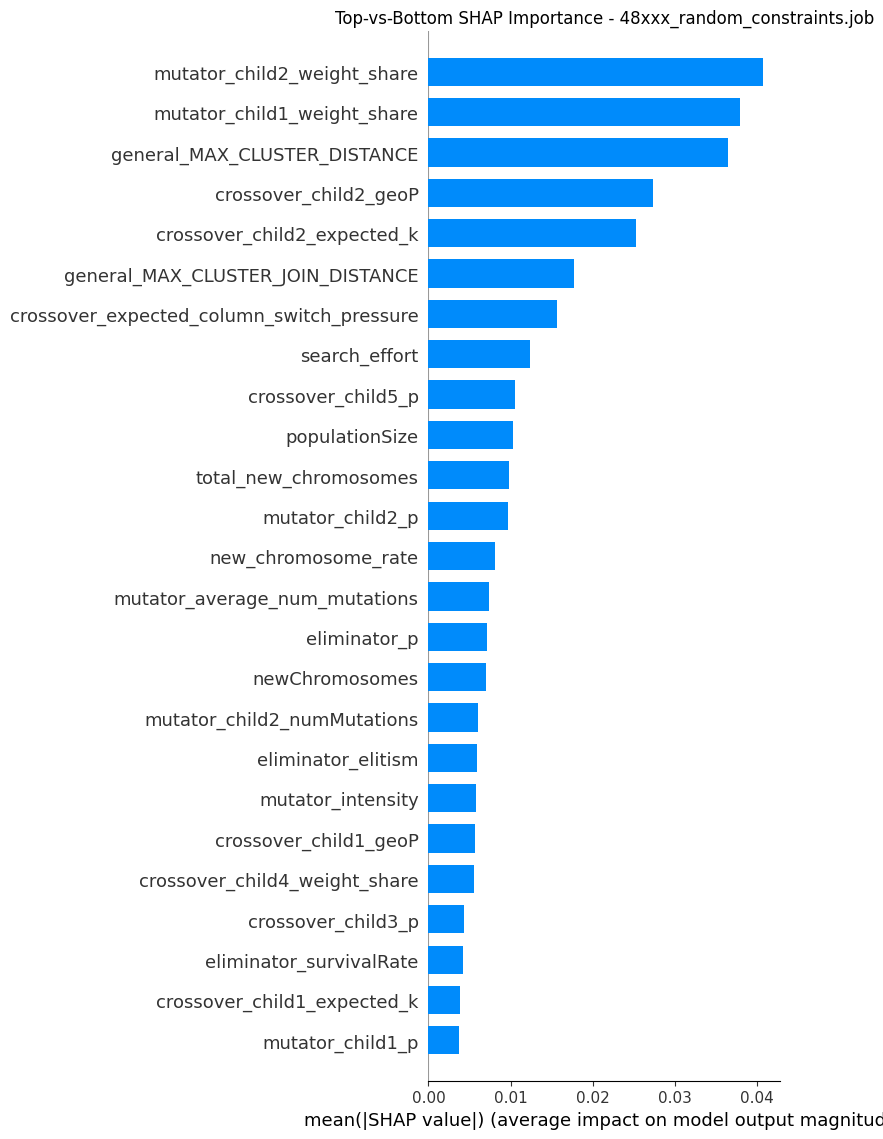

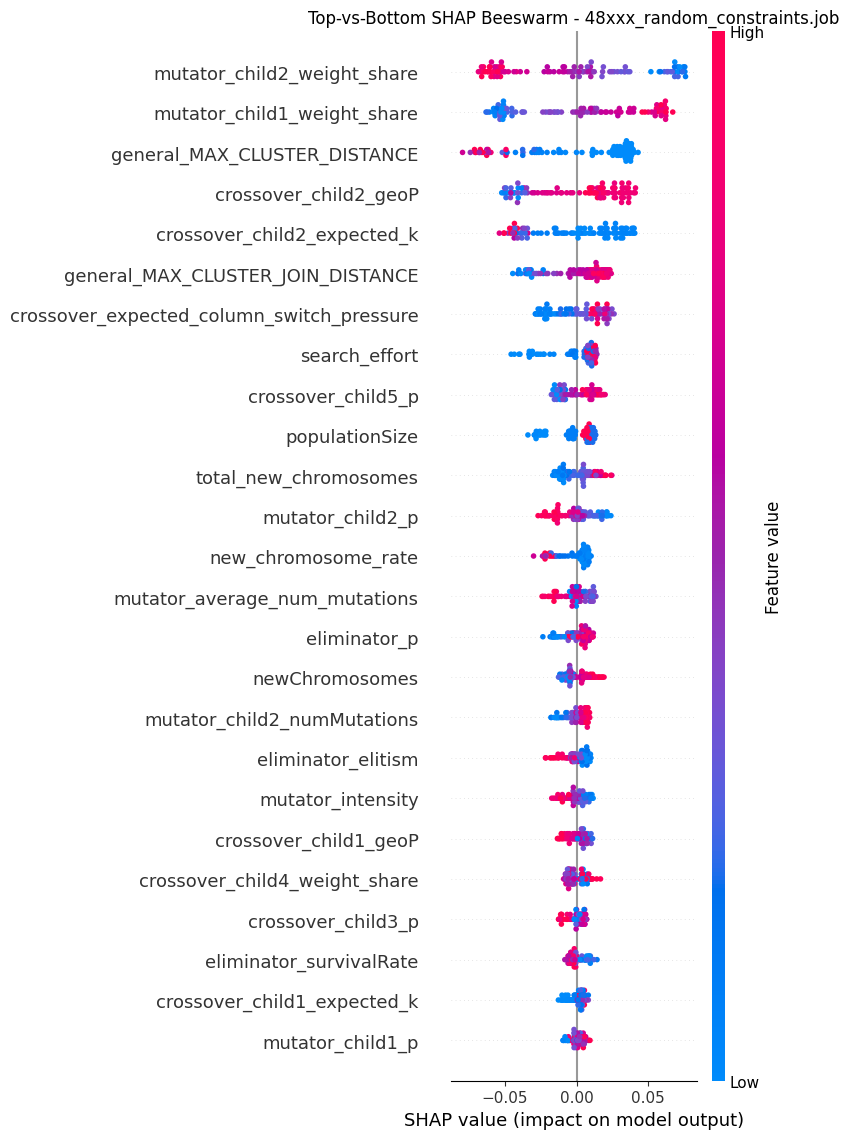

51000_rijeka_random_constraints.job: top-vs-bottom classifier train AUC = 0.990 (102 rows)


,mean_abs_shap_for_top_class
general_MAX_CLUSTER_DISTANCE,0.097926
crossover_child2_geoP,0.024621
crossover_child2_expected_k,0.022811
crossover_child1_crossoverProb,0.018993
crossover_child3_p,0.013820
crossover_expected_column_switch_pressure,0.013052
crossover_child2_crossoverProb,0.012103
general_MAX_CLUSTER_JOIN_DISTANCE,0.011737
mutator_child2_numMutations,0.010787
crossover_child3_weight_share,0.010764


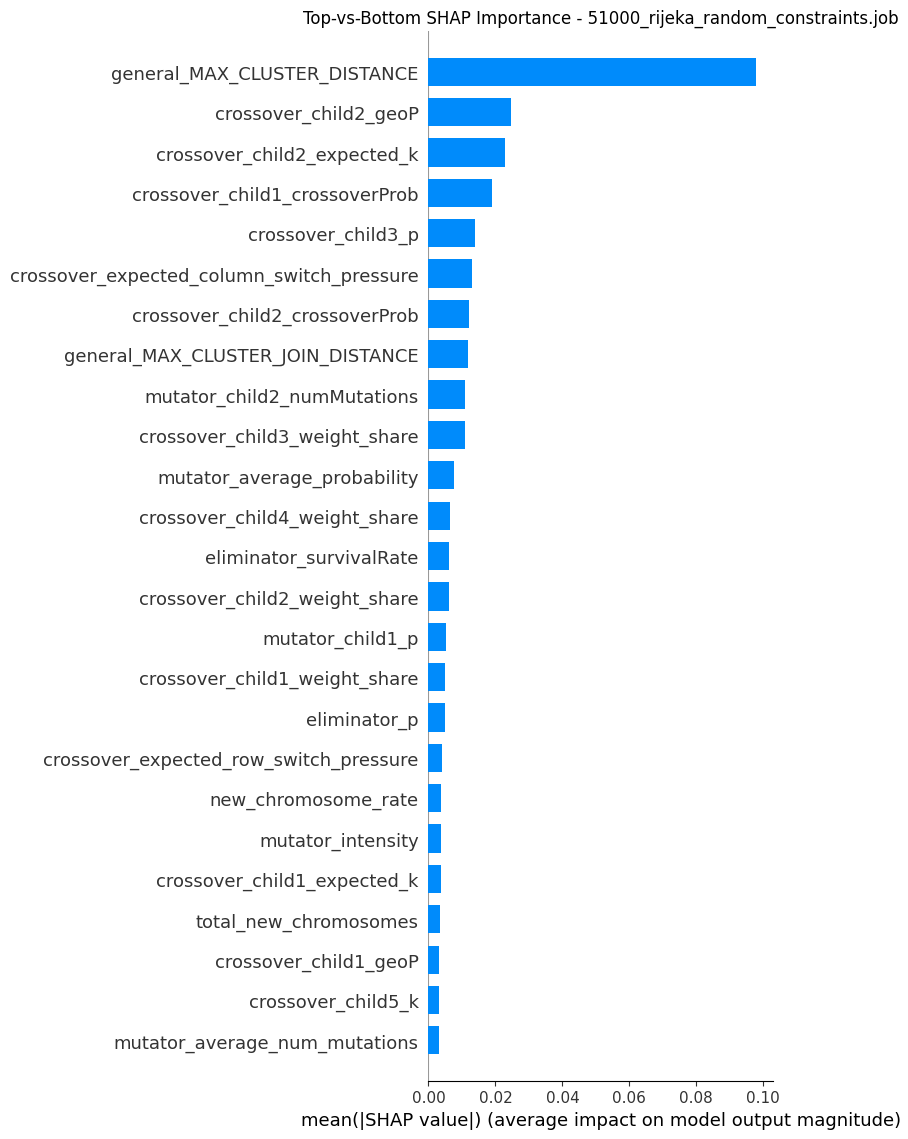

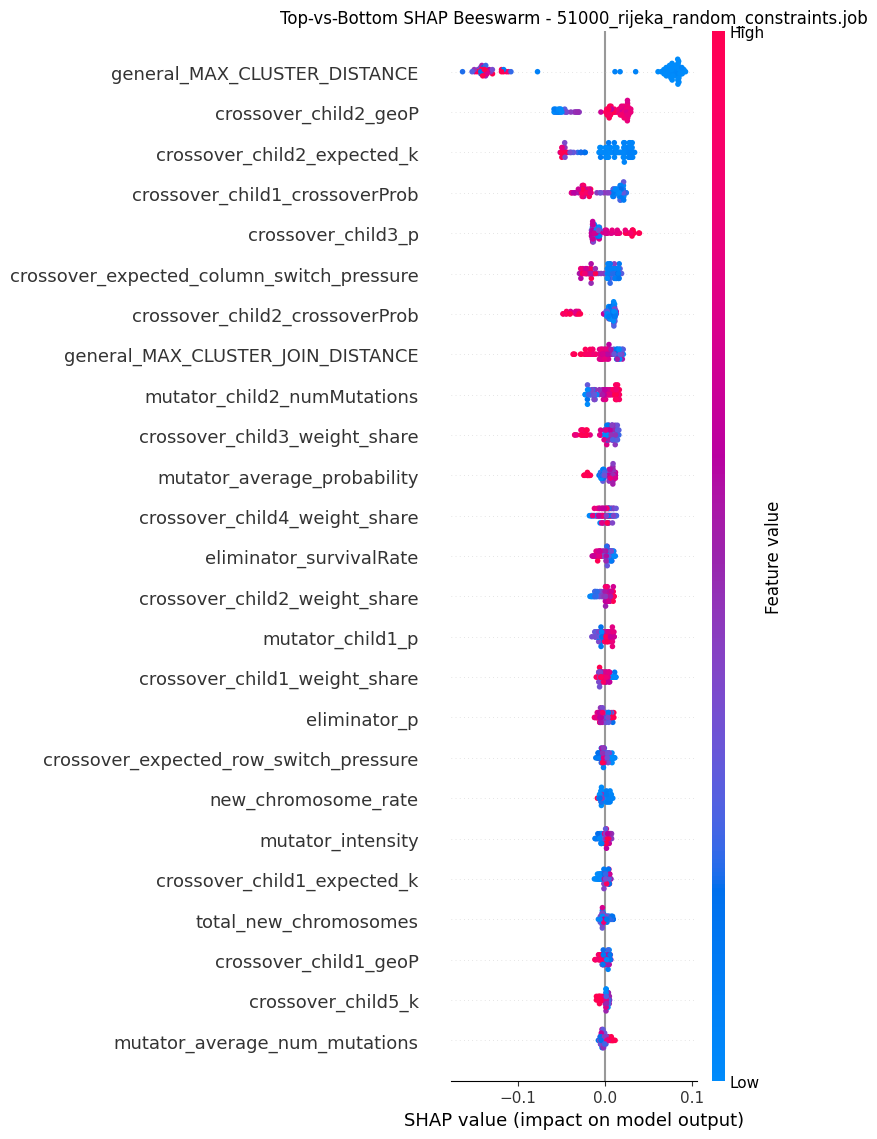

In [11]:
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


classifier_feature_cols = existing_columns(
    analysis_df,
    [
        *scoreboard_features,
        'selection_type',
        'eliminator_type',
    ],
)

for target_col in target_cols:
    target_label = fitness_labels.get(target_col, target_col)
    grouped, low_threshold, high_threshold = top_bottom_frame(analysis_df, target_col)
    model_data = grouped[classifier_feature_cols + ['quartile_group']].copy()
    y = (model_data['quartile_group'] == 'Top 25%').astype(int)
    X_raw = model_data.drop(columns=['quartile_group'])
    X = pd.get_dummies(X_raw, drop_first=False)
    X = X.apply(pd.to_numeric, errors='coerce')
    model_frame = pd.concat([X, y.rename('is_top_quartile')], axis=1).dropna()

    if len(model_frame) < 20 or model_frame['is_top_quartile'].nunique() < 2:
        print(f'Skipping {target_label}: not enough complete top/bottom rows')
        continue

    X_model = model_frame.drop(columns=['is_top_quartile'])
    y_model = model_frame['is_top_quartile']
    classifier = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=max(1, min(5, len(model_frame) // 20)),
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )
    classifier.fit(X_model, y_model)
    top_probability = classifier.predict_proba(X_model)[:, 1]
    train_auc = roc_auc_score(y_model, top_probability)
    print(f'{target_label}: top-vs-bottom classifier train AUC = {train_auc:.3f} ({len(model_frame)} rows)')

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_model)
    if isinstance(shap_values, list):
        top_class_shap_values = shap_values[1]
    elif getattr(shap_values, 'ndim', 0) == 3:
        top_class_shap_values = shap_values[:, :, 1]
    else:
        top_class_shap_values = shap_values

    mean_abs_shap = pd.Series(
        np.abs(top_class_shap_values).mean(axis=0),
        index=X_model.columns,
    ).sort_values(ascending=False)
    display(mean_abs_shap.head(25).to_frame('mean_abs_shap_for_top_class'))

    shap.summary_plot(
        top_class_shap_values,
        X_model,
        plot_type='bar',
        max_display=25,
        show=False,
    )
    plt.title(f'Top-vs-Bottom SHAP Importance - {target_label}')
    plt.tight_layout()
    plt.show()

    shap.summary_plot(
        top_class_shap_values,
        X_model,
        max_display=25,
        show=False,
    )
    plt.title(f'Top-vs-Bottom SHAP Beeswarm - {target_label}')
    plt.tight_layout()
    plt.show()
